*NATURAL LANGUAGE PROCESSING* - A.Y. 2022/2023

prof. Mark Carman, Vincenzo Scotti

---



Mathematical Engineering, Politecnico di Milano


Notebook by: **Samuele Brunati, Marta Cerri, Pietro Devecchi, Sofia Moroni**

---



---



The Semantic Textual Similarity consists of predicting the similarity between a pair of sentences. 

This Notebook is organised in the following way: at the beginning we quickly explore the dataset and we introduce word embedding in general. Then we address supervised/unsupervised learning. In particular here an index with the "chapters" that follows:



*   Explore the dataset

*   Word Embedding

*   UNSUPERVISED LEARNING

>> TF-IDF

>>> Pre-processing 1

>>> Pre-processing 2 (consider numbers)

>>> Bi-grams

>>> Tri-grams

>> Word Mover Distance

*   SUPERVISED LEARNING

>> Linear Models

>>> Logistic regression

>>> Support Vector Machine (with non-linear kernel)

>> Trasformers (for regression)

>>> Bi-encoder

>>> Cross-encoder 1

>>> Cross-encoder 2

>>> Cross-encoder...with ktrain

>>> Cross-encoder...with chatGPT

>>> Regression with Neural Network

>> Transformers (for classification)

>>> ...with SentenceTransormers

>>> ...with ktrain

*   Summary

*   Developements










In [ ]:
from google.colab import drive
drive.mount('/gdrive')

#%cd /gdrive/MyDrive/Colab Notebooks/Project NLP

#%cd /gdrive/MyDrive/Project

%cd /gdrive/My Drive/NLP/project/

#%cd /gdrive/My Drive/Colab Notebooks/NLP/Project



**Import dataset (STS benchmark)** 

STS Benchmark dataset comprises a selection of the English datasets used in the STS tasks organized in the context of SemEval between 2012 and 2017.
The dataset consists of pairs of sentences that have been judged by humans on how similar they are to one another. The fourth column of the dataset contains the similarity values (range 0-5) that indicate the level of (semantic) agreement between the meaning of the sentences.

In [ ]:
!tar xvzf Stsbenchmark.tar.gz

In [ ]:
import pandas as pd
from csv import QUOTE_NONE

df_train=pd.read_csv('stsbenchmark/sts-train.csv', sep='\t', header=None, quoting=QUOTE_NONE, usecols=[0,1,2,3,4,5,6])

df_train

,0,1,2,3,4,5,6
0,main-captions,MSRvid,2012test,1,5.00,A plane is taking off.,An air plane is taking off.
1,main-captions,MSRvid,2012test,4,3.80,A man is playing a large flute.,A man is playing a flute.
2,main-captions,MSRvid,2012test,5,3.80,A man is spreading shreded cheese on a pizza.,A man is spreading shredded cheese on an uncoo...
3,main-captions,MSRvid,2012test,6,2.60,Three men are playing chess.,Two men are playing chess.
4,main-captions,MSRvid,2012test,9,4.25,A man is playing the cello.,A man seated is playing the cello.
...,...,...,...,...,...,...,...
5744,main-news,headlines,2016,1456,0.00,Severe Gales As Storm Clodagh Hits Britain,Merkel pledges NATO solidarity with Latvia
5745,main-news,headlines,2016,1465,0.00,Dozens of Egyptians hostages taken by Libyan t...,Egyptian boat crash death toll rises as more b...
5746,main-news,headlines,2016,1466,0.00,President heading to Bahrain,President Xi: China to continue help to fight ...
5747,main-news,headlines,2016,1470,0.00,"China, India vow to further bilateral ties",China Scrambles to Reassure Jittery Stock Traders


The provided dataset was already divided into training, validation and test set

In [ ]:
df_val=pd.read_csv('stsbenchmark/sts-dev.csv', sep='\t', header=None, quoting=QUOTE_NONE, usecols=[0,1,2,3,4,5,6])

#df_val

In [ ]:
df_test=pd.read_csv('stsbenchmark/sts-test.csv', sep='\t', header=None, quoting=QUOTE_NONE, usecols=[0,1,2,3,4,5,6])

#df_test

In [ ]:
print("#Train instances: ", len(df_train[0]))
print("#Validation instances: ", len(df_val[0]))
print("#Test instances: ", len(df_test[0]))

#Train instances:  5749
#Validation instances:  1500
#Test instances:  1379


# Explore the dataset

In [ ]:
x_train = df_train[[5, 6]].values
x_train = list(map(tuple, x_train))

In [ ]:
#labels
y_train = df_train[4].values

Have a look at a random sentence pair:

In [ ]:
import random 
i = random.randint(0, len(x_train)-1)
print("Sentence 1: "+x_train[i][0])
print("Sentence 2: "+x_train[i][1])
print("Label:      "+str(y_train[i]))

Sentence 1: . What is your definition of "life force"?
Sentence 2: What is your definition of "soul"?
Label:      3.6


## Graphical exploration

The first column of the dataset specifies the domains from which the sentences have been sourced: image captions, news headlines and user forums.


In [ ]:
source = df_train[0]

In [ ]:
from collections import Counter

source_count = Counter(source)

source_count

Counter({'main-captions': 2000, 'main-forum': 450, 'main-news': 3299})

Let's have a look at how the three genres are distributed in the training set

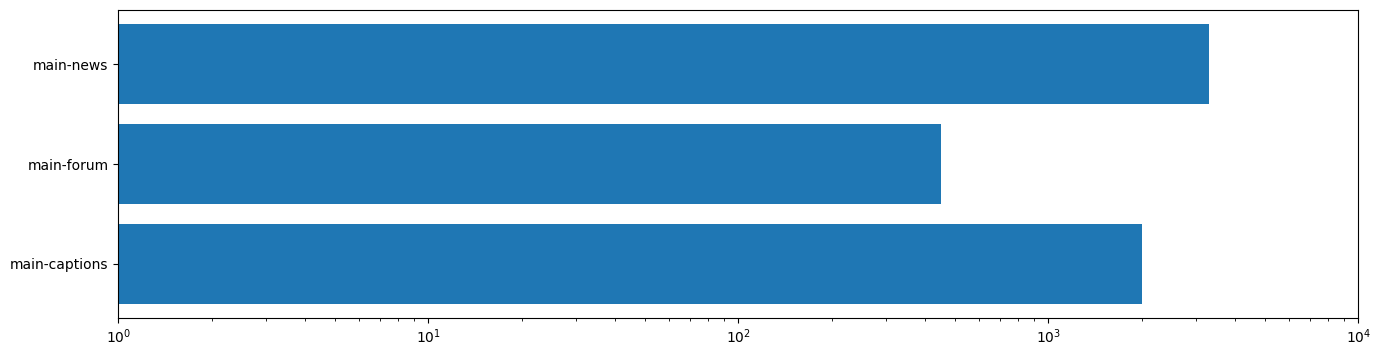

In [ ]:
from matplotlib import pyplot as plt

plt.figure(figsize=(16, 4))
plt.barh(range(len(source_count)), source_count.values())
plt.yticks(range(len(source_count)), source_count.keys())
plt.xscale('log')
plt.xlim([1, 10000])
plt.show()

Dataset 
       train  dev test total 
       -----------------------------
       news     3299  500  500  4299
       caption  2000  625  625  3250
       forum     450  375  254  1079
       -----------------------------
       total    5749 1500 1379  8628

# Word Embedding

In this section we explore the embedding space. In particular, we wanted to follow the analysis proposed in Lab Notebook 8.

In [ ]:
x_train = df_train[[5, 6]].values

type(x_train)

numpy.ndarray

In [ ]:
x_train = list(map(tuple, x_train))

type(x_train)

list

In [ ]:
!pip install -U sentence-transformers
!pip install datasets
!pip install hnswlib

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
from sentence_transformers import SentenceTransformer, util
import torch

model = SentenceTransformer('all-mpnet-base-v2')

Create the embedding of the sentences in the training set

In [ ]:
x_train_embeddings = model.encode(x_train, convert_to_tensor=True)
x_train_embeddings.size()

torch.Size([5749, 768])

In [ ]:
x_train_embeddings[0]

tensor([-2.7222e-03, -1.3639e-02,  2.2925e-02,  6.1566e-02,  1.2551e-02,
        -2.3751e-02, -3.0585e-04, -2.0162e-02, -1.0591e-01, -1.8118e-02,
         9.6496e-03, -2.9060e-02,  1.4223e-02,  4.9670e-02,  3.2431e-02,
        -7.4225e-02,  1.2620e-02, -6.8442e-02, -2.9021e-02, -1.1342e-03,
         1.0905e-02,  3.9505e-02, -4.6093e-02,  3.7505e-02, -1.5270e-03,
        -3.5277e-02,  1.3175e-02,  2.5808e-04,  3.8118e-02,  4.5291e-02,
         6.7521e-03, -1.6220e-02,  6.9518e-02,  1.9741e-02,  1.8946e-06,
        -1.6311e-02,  8.3466e-03,  5.2417e-03, -3.9218e-02, -3.1366e-02,
         2.6839e-02,  4.4838e-02, -7.2726e-04,  1.0688e-03,  9.9512e-03,
        -3.1247e-02, -3.6865e-02,  4.7184e-02,  4.9213e-02,  4.1979e-02,
         5.1443e-03, -3.6452e-02,  8.3341e-03,  4.4448e-02,  1.3155e-02,
        -1.8720e-02,  1.0155e-02, -5.5216e-02, -6.7735e-02, -3.3414e-02,
         6.0662e-03, -2.1218e-02, -1.8646e-02, -2.4499e-02,  2.5823e-02,
         7.0603e-02, -2.3040e-02,  1.7316e-02, -6.6

## Similarity matrix

In [ ]:
similarity_matrix = torch.vstack(
    [util.cos_sim(embedding, x_train_embeddings)[0] for embedding in x_train_embeddings]
)
similarity_matrix.size()

torch.Size([5749, 5749])

<ipython-input-120-a1dbb2aaca2d>:8: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


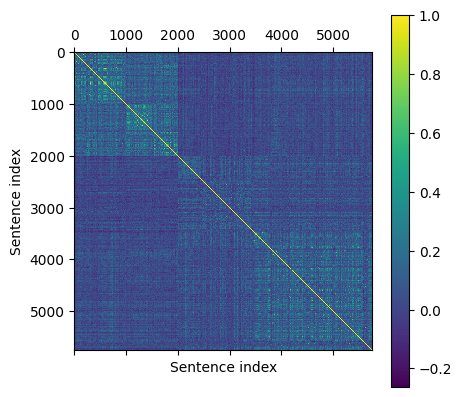

In [ ]:
from matplotlib import pyplot as plt
%matplotlib inline

plt.matshow(similarity_matrix.cpu().numpy())
plt.xlabel('Sentence index')
plt.ylabel('Sentence index')
plt.colorbar()
plt.tight_layout()

Apparently, three different "classes" are identified...

In [ ]:
x_train_1 = df_train[5]
x_train_2 = df_train[6]
x_train_1 = list(x_train_1)
x_train_2 = list(x_train_2)

Now consider each sentences as unique

In [ ]:
x_train_1_embeddings = model.encode(x_train_1, convert_to_tensor=True)
x_train_2_embeddings = model.encode(x_train_2, convert_to_tensor=True)

## A first STS regression

Compute similarity bewteen sentences

In [ ]:
cos_sim_scores = []

for i in range(len(x_train_1)):
  cos_sim_scores.append( util.cos_sim(x_train_1_embeddings[i], x_train_2_embeddings[i]).item() )

Rescale scores in 0-1

In [ ]:
y_train = df_train[4].values

y_train = y_train/5.0

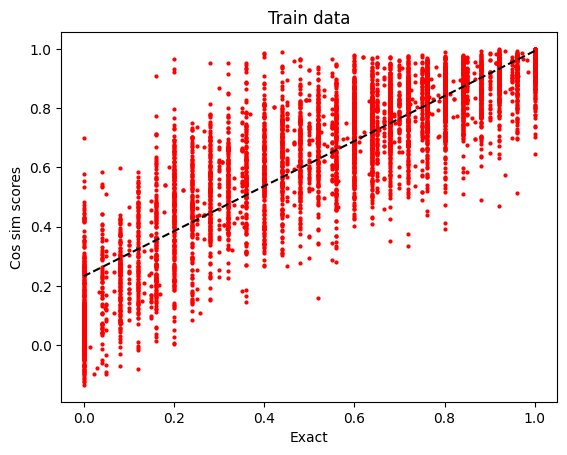

0.760703697890183 0.23255145909251299


In [ ]:
import matplotlib.pyplot as plt
  
plt.plot(y_train, cos_sim_scores, 'or', markersize=2)
#plt.axis([0, 5, 0, 5])
plt.xlabel('Exact')
plt.ylabel('Cos sim scores')
plt.title('Train data')

[m,q]=np.polyfit(y_train, cos_sim_scores,1)
plt.plot(y_train, m*y_train+q, '--k')

plt.show()

print(m, q)

## Visualize the embedding space

In [ ]:
#for what follows: convert x_train_embeddings that is of type tensor to type array
#... model.encode(x_train_2, convert_to_tensor=True).cpu().numpy()
x_train_1_embeddings = x_train_1_embeddings.cpu().numpy()
x_train_2_embeddings = x_train_2_embeddings.cpu().numpy()

In [ ]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=3, n_iter=500)
tsne_1_embedding = tsne.fit_transform(x_train_1_embeddings)
tsne_2_embedding = tsne.fit_transform(x_train_2_embeddings)

In [ ]:
!pip install plotly

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
import numpy as np
import plotly.express as px

x1, y1, z1 = np.transpose(tsne_1_embedding)
x2, y2, z2 = np.transpose(tsne_2_embedding)

fig = px.scatter_3d(x=x1, y=y1, z=z1)
fig.update_traces(marker=dict(size=3,line=dict(width=2)))
fig.show()

Plot only some sentences

In [ ]:
# Select ranomly the sentences
embed_idxs = np.random.choice(np.arange(len(tsne_1_embedding)), 10)
#sent_idxs = np.arange(0, len(sentences), 300)[embed_idxs]
color1 = np.zeros(10)
color2 = np.ones(10)

In [ ]:
# Plot the selected sentences
fig = px.scatter_3d(x=np.concatenate([x1[embed_idxs],x2[embed_idxs]]), 
                    y=np.concatenate([y1[embed_idxs],y2[embed_idxs]]), 
                    z=np.concatenate([z1[embed_idxs],z1[embed_idxs]]), 
                    text=np.concatenate([embed_idxs, embed_idxs]),
                    color=np.concatenate([color1,color2]))

fig.update_traces(marker=dict(size=3,line=dict(width=2)))
fig.show()

In [ ]:
for j in embed_idxs:
    print(f"idx={j}:\t\"{df_train[5][j]}\"\t\"{df_train[6][j]}\"")
    print(f"Cos similarity score={cos_sim_scores[j]}\t Exact_score={y_train[j]}\"")
    print("\n")

idx=5135:	"Pro-Russians forces enter Ukrainian naval base in Crimea"	"Crimean forces storm Ukrainian navy headquarters"
Cos similarity score=0.7466535568237305	 Exact_score=0.76"


idx=3281:	""PNC regrets its involvement" in the deals, Chairman and Chief Executive Officer James Rohr said in a statement."	"James Rohr, chairman and chief executive officer, said PNC regretted the incident."
Cos similarity score=0.8346474170684814	 Exact_score=0.8666"


idx=2273:	"The government does not determine if you are married or not."	"The government doesnt have to declare you married before you can be married."
Cos similarity score=0.8145153522491455	 Exact_score=0.72"


idx=5186:	"Rock bands' plane makes emergency landing in Ill."	"Rock Bands' Plane Makes Emergency Landing in Ill."
Cos similarity score=1.0000001192092896	 Exact_score=1.0"


idx=3662:	"russia ratified the amended version of the treaty. "	"russia ratified the amended treaty."
Cos similarity score=0.9736277461051941	 Exact_score=1.0"

## Semantic search

Contextual embedding models allow for semantic search.

We can use the cosine similarity between the embeddings of sentences to search for similarities exploting semantics (meaning) rather than syntax.

Altrantively, instead of encoding separately the sentences, we can learn a model that works on both at the same time and predicts directly the matching score.

**Cosine similarity search**

We can use an encoder model like BERT to extract the emebeddings of two sentences seprately and compare them though cosine similarity. 

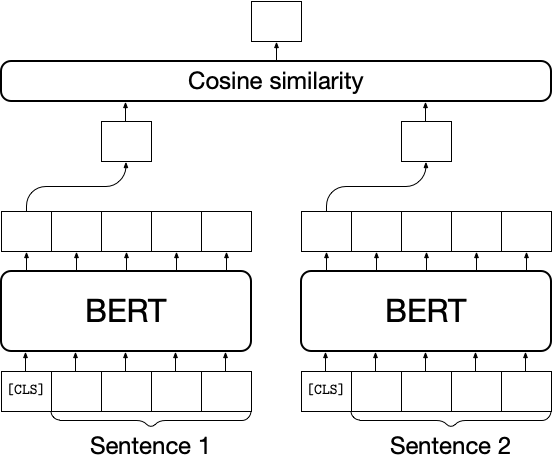

Note that since sentences are encoded separately one from the other, we can pre-compute the embeddings forming some sort of indexed data base and exploit the pre computed embeddings for a later search.

**Speed up cosine similarity**

We can speed-up the process by pre-nomalising the embeddings and compute directly the dot-product instead of cosine similarity.

**Cross-encoder**

Cross encoder models work by encoding together the sentences in a pair or a document-query pair.

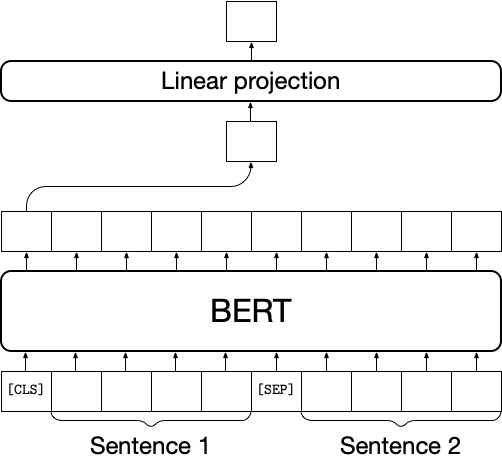

Differently from the previous models that can be trained either with a supervised approach or with an unsupervised appraoch, in this case they only work if trained for some supervised target like classification (e.g., paraphrase detection) or regression (e.g., sentence similarity).

# Unsupervised learning

Unsupervised techniques for semantic text similarity aim to measure the similarity between sentences without relying on labeled training data.

In this part we discuss a few techniques that consider just the actual words to compute the similarity score, without considering the context in which the word appears. As we will see, these techniques have worse performance than more modern contextual approaches.

We first concatenate the paired sentences in just one list that we will need as input in the unsupervised models.

In [ ]:
x_train_1 = list(df_train[5])
x_train_2 = list(df_train[6])

x_train=x_train_1 + x_train_2

In [ ]:
x_val_1 = list(df_val[5])
x_val_2 = list(df_val[6])

x_val=x_val_1 + x_val_2

In [ ]:
x_test_1 = list(df_test[5])
x_test_2 = list(df_test[6])

x_test=x_test_1 + x_test_2

## TF-IDF cosine similarity

The first techinique is the cosine similarity between TF-IDF bag-of-words vectors for the sentences.                                                      
We used the TFIDF vectorizer. It maps each unique word to a unique vector index and the values of the vector are the product of two values: Term Frequency (TF) and Inverse Document Frequency (IDF).

Below we distinguish two cases that differ in the preprocessing step and then we extend the BOW vector representation including bigrams and trigrams.

Import useful libraries

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer           #object that builds the BOW representation

from sklearn.feature_extraction.text import TfidfVectorizer   
vectorizer = TfidfVectorizer()

from sklearn.metrics.pairwise import cosine_similarity
import spacy
nlp = spacy.load("en_core_web_sm")

import numpy as np

We define a function to compute cosine similarity between sentences

In [ ]:
def cos_sim(sentence1_emb, sentence2_emb):
    """
    Cosine similarity between two columns of sentence embeddings
    
    Args:
      sentence1_emb: sentence1 embedding column
      sentence2_emb: sentence2 embedding column
    
    Returns:
      The row-wise cosine similarity between the two columns.
      For instance is sentence1_emb=[a,b,c] and sentence2_emb=[x,y,z]
      Then the result is [cosine_similarity(a,x), cosine_similarity(b,y), cosine_similarity(c,z)]
    """
    cos_sim = cosine_similarity(sentence1_emb, sentence2_emb)
    return np.diag(cos_sim)

### Case 1

Here we preprocess the sentences by just removing the stop_words='english' list of the function TfidfVectorizer from sklearn.feature_extraction.text library.

In [ ]:
vectorizer = TfidfVectorizer(stop_words='english')

We use the training set in order to learn the vocabulary

In [ ]:
vectorizer.fit(x_train)

len(vectorizer.get_feature_names_out())

11134

Now that we learnt the vocabulary based on the training set, we generate the bag-of-word/vector representation for each pair of sentences of the validation set.

In [ ]:
BOW_A = vectorizer.transform(x_val_1)      #each row is the BOW representation
BOW_A

<1500x11134 sparse matrix of type '<class 'numpy.float64'>'
	with 7860 stored elements in Compressed Sparse Row format>

In [ ]:
BOW_B = vectorizer.transform(x_val_2)     #each row is the BOW representation

Compute the cosine similarity bewteen the two word embeddings

In [ ]:
df_val['TFIDF similarity CASE 1'] = 5*cos_sim(BOW_A, BOW_B)

df_val

,0,1,2,3,4,5,6,TFIDF similarity CASE 1
0,main-captions,MSRvid,2012test,0,5.00,A man with a hard hat is dancing.,A man wearing a hard hat is dancing.,4.535668
1,main-captions,MSRvid,2012test,2,4.75,A young child is riding a horse.,A child is riding a horse.,4.350041
2,main-captions,MSRvid,2012test,3,5.00,A man is feeding a mouse to a snake.,The man is feeding a mouse to the snake.,5.000000
3,main-captions,MSRvid,2012test,7,2.40,A woman is playing the guitar.,A man is playing guitar.,3.936542
4,main-captions,MSRvid,2012test,8,2.75,A woman is playing the flute.,A man is playing a flute.,4.140671
...,...,...,...,...,...,...,...,...
1495,main-news,headlines,2016,1283,2.00,Scientists prove there is water on Mars,Has Nasa discovered water on Mars?,2.083070
1496,main-news,headlines,2016,1434,0.00,Pranab stresses need to strive for peace by na...,WTO: India regrets action of developed nations,1.335834
1497,main-news,headlines,2016,1440,2.00,Volkswagen skids into red in wake of pollution...,"Volkswagen's ""gesture of goodwill"" to diesel o...",0.000000
1498,main-news,headlines,2016,1477,0.00,Obama is right: Africa deserves better leadership,Obama waiting for midterm to name attorney gen...,0.625308


Let's have a look at which words we have removed

In [ ]:
stop_w_list = TfidfVectorizer(stop_words='english').get_stop_words()

print(stop_w_list)

frozenset({'might', 'every', 'twelve', 'whoever', 'sometimes', 'whereby', 'thereafter', 'many', 'ever', 'himself', 'sixty', 'an', 'hundred', 'upon', 'yours', 'full', 'three', 'cant', 'yourself', 'put', 'all', 'around', 'interest', 'therein', 'hence', 'inc', 'fifteen', 'beside', 'wherein', 'third', 'who', 'during', 'con', 'noone', 'anyway', 'of', 'onto', 'down', 'five', 'fill', 'became', 'hereby', 'over', 'together', 'detail', 'were', 'someone', 'these', 'and', 'seeming', 'is', 'them', 'ten', 'name', 'whole', 'neither', 'anywhere', 'whereupon', 'ie', 'least', 'as', 'part', 'become', 'each', 'being', 'because', 'nothing', 'it', 'here', 'hereupon', 'without', 'nor', 'nobody', 'co', 'my', 'there', 'hers', 'made', 'whence', 'whereafter', 'very', 'been', 'am', 'could', 'becoming', 'under', 'thus', 'last', 'thereupon', 'several', 'herself', 'by', 'the', 'enough', 'be', 'rather', 'get', 'fire', 'namely', 'first', 'via', 'nevertheless', 'describe', 'done', 'off', 'seem', 'always', 'across', 'tw

In the list of stop words there are also the numbers and we realized that they are relevant to correclty predict the similarity

In [ ]:
a0 = 'two men are playing piano'
a1 = 'three men are playing piano'
#use the vectorize object to transofrm the tweets into BOW
transformed_a1 = vectorizer.transform([a0])
transformed_a2 = vectorizer.transform([a1])
#prediction using the model
predictions = cos_sim(transformed_a1,transformed_a2)

print(predictions)

[1.]


Indeed in this case the prediction is 1 even if the two sentences are the description of different instances.

To solve the problem we looked for a set of stop words that didn't consider numbers and we perform a new BOW.

### Case 2

To include the numbers we wrote a function called "my_text_processing(sentence)". It first tokenizes the sentence, removes the stop words (the list of stop words here is different to the one of Case 1. For example it does not remove the numbers), convert the tokens to lower case and remove the puntuaction. At the end it returns the preprocessed sentence.


In [ ]:
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
def my_text_processing(sentence):
    # Tokenization & Lemmatization
    tokens=[token.lemma_.lower() for token in nlp(sentence)]

    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [token for token in tokens if token.lower() not in stop_words]

    # Convert to lowercase
    tokens = [token.lower() for token in tokens]

    # Remove punctuation
    tokens = [token for token in tokens if token.isalpha()]

    # Join tokens back into a preprocessed sentence
    preprocessed_sentence = ' '.join(tokens)

    return preprocessed_sentence

#### Visualize the effects of pre-processing

Have a look to how sentences change with the pre-processing

Focus on a sentence with numbers

In [ ]:
b = 'Two men are playing piano'

b1 = my_text_processing(b)

print("Sentence --> "+b)
print("Sentence (pre-processing) --> "+b1)

Sentence --> Two men are playing piano
Sentence (pre-processing) --> two man play piano


As we desired, now numbers are kept in the pre-preprocessed sentences.

#### Bag-of-words

Now we train TfidfVectorized on the preprocessed training set.

In [ ]:
prep_train = list(map(my_text_processing, x_train))

In [ ]:
prep_val_1 = list(map(my_text_processing, x_val_1))
prep_val_2 = list(map(my_text_processing, x_val_2))

In [ ]:
vectorizer = TfidfVectorizer()

We obtain a vocabulary with the following length:

In [ ]:
vectorizer.fit(prep_train)         
len(vectorizer.get_feature_names_out())

8745

We evaluate it using the validation set. We obtain the TFIDF-BOW representation of the first column of sentences (BOW_A) and of the second column (BOW_B).

In [ ]:
BOW_A = vectorizer.transform(prep_val_1)      #each row is the BOW representation of a sentence
BOW_A

<1500x8745 sparse matrix of type '<class 'numpy.float64'>'
	with 8557 stored elements in Compressed Sparse Row format>

In [ ]:
BOW_B = vectorizer.transform(prep_val_2)
BOW_B

<1500x8745 sparse matrix of type '<class 'numpy.float64'>'
	with 8445 stored elements in Compressed Sparse Row format>

Compute cosine similarity

In [ ]:
df_val['TFIDF similarity CASE 2'] = 5*cos_sim(BOW_A, BOW_B)

df_val

,0,1,2,3,4,5,6,TFIDF similarity CASE 1,TFIDF similarity CASE 2
0,main-captions,MSRvid,2012test,0,5.00,A man with a hard hat is dancing.,A man wearing a hard hat is dancing.,4.535668,4.537706
1,main-captions,MSRvid,2012test,2,4.75,A young child is riding a horse.,A child is riding a horse.,4.350041,4.289690
2,main-captions,MSRvid,2012test,3,5.00,A man is feeding a mouse to a snake.,The man is feeding a mouse to the snake.,5.000000,5.000000
3,main-captions,MSRvid,2012test,7,2.40,A woman is playing the guitar.,A man is playing guitar.,3.936542,3.952116
4,main-captions,MSRvid,2012test,8,2.75,A woman is playing the flute.,A man is playing a flute.,4.140671,4.162463
...,...,...,...,...,...,...,...,...,...
1495,main-news,headlines,2016,1283,2.00,Scientists prove there is water on Mars,Has Nasa discovered water on Mars?,2.083070,2.111740
1496,main-news,headlines,2016,1434,0.00,Pranab stresses need to strive for peace by na...,WTO: India regrets action of developed nations,1.335834,0.894464
1497,main-news,headlines,2016,1440,2.00,Volkswagen skids into red in wake of pollution...,"Volkswagen's ""gesture of goodwill"" to diesel o...",0.000000,0.000000
1498,main-news,headlines,2016,1477,0.00,Obama is right: Africa deserves better leadership,Obama waiting for midterm to name attorney gen...,0.625308,0.602066


**Note:** in both *Case 1* and *Case 2* we decided to remove as inputs of the TFIDF model the word frequency parameters **max_df** and **min_df**, since our "documents" are simply short sentences (anyway we also tried to play with them, but the results didn't change at all).

### Bi-grams

We extended the TFIDF BOW taking into the vocabulary also the Bigrams. 


We first preprocess the dataset exploiting again the function *my_text_preprocessing(sentence)*.

In [ ]:
prep_train = list(map(my_text_processing, x_train))

In [ ]:
prep_val_1 = list(map(my_text_processing, x_val_1))
prep_val_2 = list(map(my_text_processing, x_val_2))

In [ ]:
vectorizer = TfidfVectorizer(ngram_range=(1, 2))
vectorizer.fit(prep_train)
     
len(vectorizer.get_feature_names_out()) 

46742

In [ ]:
BOW_A = vectorizer.transform(prep_val_1)
BOW_B = vectorizer.transform(prep_val_2)

In [ ]:
df_val['Bigram-TFIDF similarity'] = 5*cos_sim(BOW_A, BOW_B)

df_val

,0,1,2,3,4,5,6,TFIDF similarity CASE 1,TFIDF similarity CASE 2,Bigram-TFIDF similarity
0,main-captions,MSRvid,2012test,0,5.00,A man with a hard hat is dancing.,A man wearing a hard hat is dancing.,4.535668,4.537706,3.811708
1,main-captions,MSRvid,2012test,2,4.75,A young child is riding a horse.,A child is riding a horse.,4.350041,4.289690,4.103681
2,main-captions,MSRvid,2012test,3,5.00,A man is feeding a mouse to a snake.,The man is feeding a mouse to the snake.,5.000000,5.000000,5.000000
3,main-captions,MSRvid,2012test,7,2.40,A woman is playing the guitar.,A man is playing guitar.,3.936542,3.952116,3.044156
4,main-captions,MSRvid,2012test,8,2.75,A woman is playing the flute.,A man is playing a flute.,4.140671,4.162463,3.422148
...,...,...,...,...,...,...,...,...,...,...
1495,main-news,headlines,2016,1283,2.00,Scientists prove there is water on Mars,Has Nasa discovered water on Mars?,2.083070,2.111740,2.111740
1496,main-news,headlines,2016,1434,0.00,Pranab stresses need to strive for peace by na...,WTO: India regrets action of developed nations,1.335834,0.894464,0.894464
1497,main-news,headlines,2016,1440,2.00,Volkswagen skids into red in wake of pollution...,"Volkswagen's ""gesture of goodwill"" to diesel o...",0.000000,0.000000,0.000000
1498,main-news,headlines,2016,1477,0.00,Obama is right: Africa deserves better leadership,Obama waiting for midterm to name attorney gen...,0.625308,0.602066,0.528881


### Tri-grams

We extended the TFIDF BOW taking into the vocabulary also the Trigrams.

In [ ]:
vectorizer = TfidfVectorizer(ngram_range=(1, 3))
vectorizer.fit(prep_train)         
len(vectorizer.get_feature_names_out()) 

85956

In [ ]:
BOW_A = vectorizer.transform(prep_val_1)
BOW_B = vectorizer.transform(prep_val_2)

In [ ]:
df_val['Trigram-TFIDF similarity'] = 5*cos_sim(BOW_A, BOW_B)

df_val

,0,1,2,3,4,5,6,TFIDF similarity CASE 1,TFIDF similarity CASE 2,Bigram-TFIDF similarity,Trigram-TFIDF similarity
0,main-captions,MSRvid,2012test,0,5.00,A man with a hard hat is dancing.,A man wearing a hard hat is dancing.,4.535668,4.537706,3.811708,3.195290
1,main-captions,MSRvid,2012test,2,4.75,A young child is riding a horse.,A child is riding a horse.,4.350041,4.289690,4.103681,3.907188
2,main-captions,MSRvid,2012test,3,5.00,A man is feeding a mouse to a snake.,The man is feeding a mouse to the snake.,5.000000,5.000000,5.000000,5.000000
3,main-captions,MSRvid,2012test,7,2.40,A woman is playing the guitar.,A man is playing guitar.,3.936542,3.952116,3.044156,2.183577
4,main-captions,MSRvid,2012test,8,2.75,A woman is playing the flute.,A man is playing a flute.,4.140671,4.162463,3.422148,2.509268
...,...,...,...,...,...,...,...,...,...,...,...
1495,main-news,headlines,2016,1283,2.00,Scientists prove there is water on Mars,Has Nasa discovered water on Mars?,2.083070,2.111740,2.111740,2.111740
1496,main-news,headlines,2016,1434,0.00,Pranab stresses need to strive for peace by na...,WTO: India regrets action of developed nations,1.335834,0.894464,0.894464,0.894464
1497,main-news,headlines,2016,1440,2.00,Volkswagen skids into red in wake of pollution...,"Volkswagen's ""gesture of goodwill"" to diesel o...",0.000000,0.000000,0.000000,0.000000
1498,main-news,headlines,2016,1477,0.00,Obama is right: Africa deserves better leadership,Obama waiting for midterm to name attorney gen...,0.625308,0.602066,0.528881,0.528881


### Comparing different models on validation set

In order to compare the results of the previous methods we compute the *Pearson Coefficient* and the *Spearman Coefficient*. The first one takes into account the linear correlation between the human similarity scores and the predicted ones. The *Spearman Coefficient* is not sensitive to outliers and takes into account non-linear relationships. 

In [ ]:
from scipy.stats import spearmanr
from scipy.stats import pearsonr

from tabulate import tabulate

In [ ]:
sp_case_1, p = spearmanr(df_val[4], df_val['TFIDF similarity CASE 1'])
pr_case_1 = pearsonr(df_val[4], df_val['TFIDF similarity CASE 1'])

sp_case_2, p = spearmanr(df_val[4], df_val['TFIDF similarity CASE 2'])
pr_case_2 = pearsonr(df_val[4], df_val['TFIDF similarity CASE 2'])

sp_bigram, p = spearmanr(df_val[4], df_val['Bigram-TFIDF similarity'])
pr_bigram = pearsonr(df_val[4], df_val['Bigram-TFIDF similarity'])

sp_trigram, p = spearmanr(df_val[4], df_val['Trigram-TFIDF similarity'])
pr_trigram = pearsonr(df_val[4], df_val['Trigram-TFIDF similarity'])


# Sample data for the table
data = [
    ["TFIDF-Model", "Pearson", "Spearman"],
    ["Case 1", pr_case_1[0], sp_case_1],
    ["Case 2",pr_case_2[0] , sp_case_2],
    ["Bigram", pr_bigram[0], sp_bigram],
    ["Trigram", pr_trigram[0], sp_trigram],
]

# Display the table
table = tabulate(data, headers="firstrow", tablefmt="fancy_grid")
print(table)


╒═══════════════╤═══════════╤════════════╕
│ TFIDF-Model   │   Pearson │   Spearman │
╞═══════════════╪═══════════╪════════════╡
│ Case 1        │  0.725862 │   0.727622 │
├───────────────┼───────────┼────────────┤
│ Case 2        │  0.741799 │   0.742052 │
├───────────────┼───────────┼────────────┤
│ Bigram        │  0.71596  │   0.72682  │
├───────────────┼───────────┼────────────┤
│ Trigram       │  0.703484 │   0.722249 │
╘═══════════════╧═══════════╧════════════╛


We observe that the best model is the one of *Case 2*.

Plot a comparison of the predictions of the different models versus the real scores.

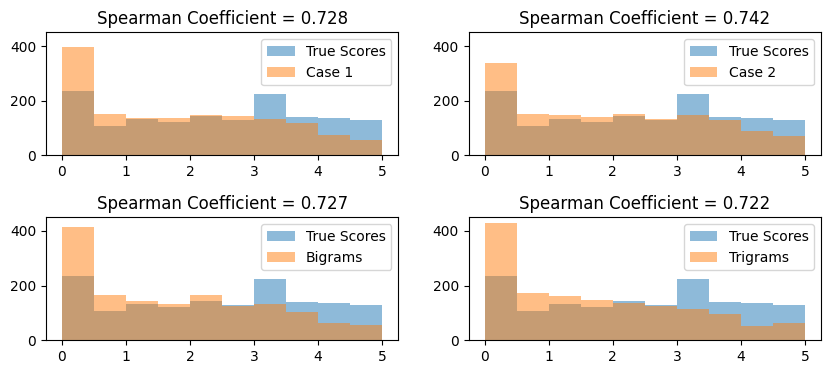

In [ ]:
import matplotlib.pyplot as plt

fig, axs=plt.subplots(2,2,figsize=(10,4))

axs[0][0].hist(df_val[4], alpha=0.5, label='True Scores')
axs[0][0].hist(df_val['TFIDF similarity CASE 1'], alpha=0.5, label='Case 1')
axs[0][0].legend()
axs[0][0].set_title('Spearman Coefficient = {:.3f}'.format(sp_case_1))
axs[0][0].set_ylim(0,450)
axs[0][1].hist(df_val[4], alpha=0.5, label='True Scores')
axs[0][1].hist(df_val['TFIDF similarity CASE 2'], alpha=0.5, label='Case 2')
axs[0][1].legend()
axs[0][1].set_title('Spearman Coefficient = {:.3f}'.format(sp_case_2))
axs[0][1].set_ylim(0,450)

axs[1][0].hist(df_val[4], alpha=0.5, label='True Scores')
axs[1][0].hist(df_val['Bigram-TFIDF similarity'], alpha=0.5, label='Bigrams')
axs[1][0].legend()
axs[1][0].set_title('Spearman Coefficient = {:.3f}'.format(sp_bigram))
axs[1][0].set_ylim(0,450)
axs[1][1].hist(df_val[4], alpha=0.5, label='True Scores')
axs[1][1].hist(df_val['Trigram-TFIDF similarity'], alpha=0.5, label='Trigrams')
axs[1][1].legend()
axs[1][1].set_title('Spearman Coefficient = {:.3f}'.format(sp_trigram))
axs[1][1].set_ylim(0,450)

plt.subplots_adjust(hspace=0.5)
plt.show()

Also these plots confirm that the second model is the best one.

### Testing the best model on the test set

Now we use the test set in order to see the performance of the best TFIDF-model

In [ ]:
prep_test_1 = list(map(my_text_processing, x_test_1))
prep_test_2 = list(map(my_text_processing, x_test_2))

In [ ]:
vectorizer = TfidfVectorizer()
vectorizer.fit(prep_train)   

TfidfVectorizer()

In [ ]:
BOW_A = vectorizer.transform(prep_test_1)
BOW_B = vectorizer.transform(prep_test_2)

In [ ]:
df_test['TFIDF similarity'] = 5*cos_sim(BOW_A, BOW_B)

df_test

,0,1,2,3,4,5,6,TFIDF similarity
0,main-captions,MSRvid,2012test,24,2.5,A girl is styling her hair.,A girl is brushing her hair.,2.546968
1,main-captions,MSRvid,2012test,33,3.6,A group of men play soccer on the beach.,A group of boys are playing soccer on the beach.,4.394012
2,main-captions,MSRvid,2012test,45,5.0,One woman is measuring another woman's ankle.,A woman measures another woman's ankle.,4.574889
3,main-captions,MSRvid,2012test,63,4.2,A man is cutting up a cucumber.,A man is slicing a cucumber.,3.576080
4,main-captions,MSRvid,2012test,66,1.5,A man is playing a harp.,A man is playing a keyboard.,1.552567
...,...,...,...,...,...,...,...,...
1374,main-news,headlines,2016,1354,0.0,"Philippines, Canada pledge to further boost re...",Philippines saves 100 after ferry sinks,1.028563
1375,main-news,headlines,2016,1360,1.0,Israel bars Palestinians from Jerusalem's Old ...,"Two-state solution between Palestinians, Israe...",1.483183
1376,main-news,headlines,2016,1368,1.0,How much do you know about Secret Service?,Lawmakers from both sides express outrage at S...,1.933940
1377,main-news,headlines,2016,1420,0.0,Obama Struggles to Soothe Saudi Fears As Iran ...,Myanmar Struggles to Finalize Voter Lists for ...,0.000000


In [ ]:
sp, p = spearmanr(df_test[4], df_test['TFIDF similarity'])

pr = pearsonr(df_test[4], df_test['TFIDF similarity'])

print("Spearman:  "+str(sp))
print("Pearson:   "+str(pr[0]))

Spearman:  0.6508065969142609
Pearson:   0.6673063879629288


As we can see the Spearman Coefficient is not so high. This may be due to the fact that TFIDF-BOW representation doesn't care about the context of the sentences and preprocessed sentences do not have many similar words.

Text(0.5, 1.0, 'Spearman Coefficient = 0.651')

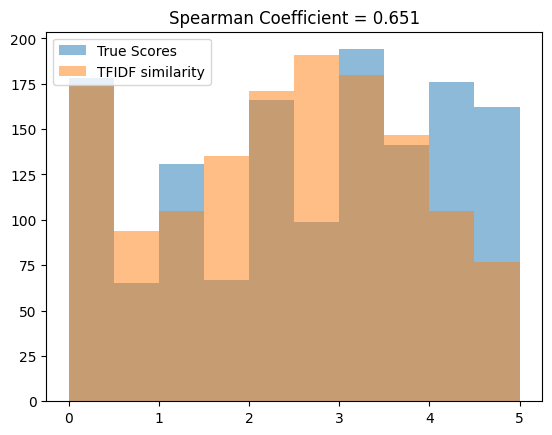

In [ ]:
# Plotting histogram
plt.hist(df_test[4], alpha=0.5, label='True Scores')
plt.hist(df_test['TFIDF similarity'], alpha=0.5, label='TFIDF similarity')
plt.legend()
plt.title('Spearman Coefficient = {:.3f}'.format(sp))

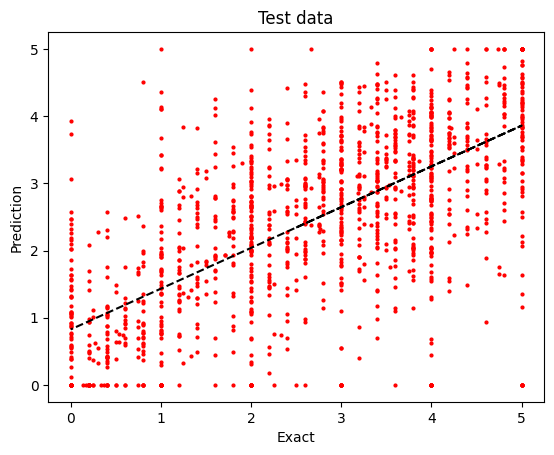

0.6065839048099766 0.8257296560840238


In [ ]:
plt.plot(df_test[4], df_test['TFIDF similarity'], 'or', markersize=2)
#plt.axis([0, 5, 0, 5])
plt.xlabel('Exact')
plt.ylabel('Prediction')
plt.title('Test data')

[m,q]=np.polyfit(df_test[4], df_test['TFIDF similarity'],1)
plt.plot(df_test[4], m*df_test[4]+q, '--k')

plt.show()

print(m, q)

From the plot above we notice that there are some sentences whose predicted score is 0 while the true one is not and viceversa.
Below we try to investigate this issue.

We select the sentences whose predicted similarity is 0 and the exact score is higher than 2.
We observe that they are very simple sentences that contain only stop words and during the preprocessing step become empty.


In [ ]:
df_test.loc[(df_test[4] > 2) & (df_test['TFIDF similarity'] == 0.00)]

,0,1,2,3,4,5,6,TFIDF similarity
117,main-captions,MSRvid,2012test,720,2.50,A man is cycling.,A boy is riding a bicycle.,0.0
494,main-captions,images,2015,1429,2.60,A boy skateboards down the railing of some gra...,A skateboarder slides down a handrail on his f...,0.0
632,main-forums,answer-answer,2016,48,3.00,You should do it.,You should do what it says.,0.0
636,main-forums,answer-answer,2016,87,5.00,"You can do it, too.","Yes, you can do it.",0.0
639,main-forums,answer-answer,2016,107,4.00,I have few suggestions for you:,I have two suggestions for you:,0.0
686,main-forums,answer-answer,2016,370,4.00,I have the same thing.,I have had the same problem.,0.0
702,main-forums,answer-answer,2016,445,4.00,How should I proceed about this?,So how should I do this?,0.0
730,main-forums,answer-answer,2016,639,3.00,This is the tip I find most useful:,Something like this is useful:,0.0
737,main-forums,answer-answer,2016,662,5.00,Can you do this?,Can you do it?,0.0
738,main-forums,answer-answer,2016,664,3.00,"Sure, I've done this very trip.",I've done this many dozens of times.,0.0


Here we display the sentences that have 0 score, but our prediction gives them a label greater than 2. This kind of issue should be further investigated...

In [ ]:
df_test.loc[(df_test[4] == 0.00) & (df_test['TFIDF similarity'] > 2)]

,0,1,2,3,4,5,6,TFIDF similarity
652,main-forums,answer-answer,2016,184,0.0,It's not a good idea.,It's a good question.,2.025705
653,main-forums,answer-answer,2016,189,0.0,It's pretty much up to you.,It's much better to ask.,2.024267
672,main-forums,answer-answer,2016,298,0.0,"The answers so far are already good, but I'd l...","You have a lot of answers already, but I'd lik...",2.567456
712,main-forums,answer-answer,2016,516,0.0,The best thing you can do is to know your stuff.,The best thing to do is to overcome the fussin...,2.476288
715,main-forums,answer-answer,2016,537,0.0,You PROBABLY don't have any chance at the moment.,"Saying ""thanks, I don't have any questions at ...",2.095351
725,main-forums,answer-answer,2016,607,0.0,What kind of insulation is it?,What kind of floors are above?,3.934251
762,main-forums,answer-answer,2016,770,0.0,You don't need any visa.,You don't need sauce at all.,3.068701
770,main-forums,answer-answer,2016,854,0.0,The answer to both questions is: Yes.,To directly answer the two questions in your t...,2.468212
779,main-forums,answer-answer,2016,879,0.0,There are a few things I think you should do.,There are a few things I don't understand:,2.323694
848,main-forums,answer-answer,2016,1356,0.0,It is impossible to answer this question witho...,This is a part answer to your question,2.154738


## Word Mover Distance

TFIDF assumes that similar texts have many words in common. This may not always be the case as even texts without any common non-stop words could be similar, as shown below. One way we can tackle this problem is by using pre-trained word embeddings.

The following approach is to compute the similarity between texts from the word embeddings called Word Movers Distance (WMD).
WMD is based on the concept of Earth Movers Distance and is the minimum distance that the word embeddings from one document need to “travel” to reach the word embeddings of the document we are comparing it to. Since each document includes multiple words, the WMD calculation needs to calculate the distances from each word to every other word. It also weights the “travel” by the term frequencies of each word.

The gensim library implements this complex computation efficiently using the Fast WMD algorithm.

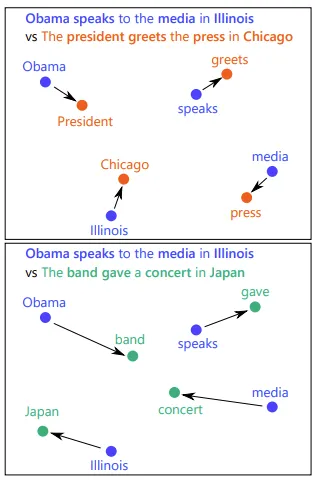

In the example both pairs of sentences have no common words. WMD can still find a similar sentence as their words are closer

We use the FastText model pre-trained on Wikipedia primarily because FastText uses sub-word information and will never run into Out Of Vocabulary issues.

In [ ]:
import gensim.downloader as api

# Load the pre-trained model
model = api.load('fasttext-wiki-news-subwords-300')

[=================================================-] 99.8% 956.4/958.4MB downloaded


We define the function that compute the Negative Word Movers Distance. It takes as input a pair of sentences, preprocesses them anco returns the similarity score multiplied by -1 (Negative WMD) so that more similar texts have numerically larger values.

In [ ]:
def word_movers_distance(row):
    # Text Processing
    sentence1 = my_text_processing(row[5])
    sentence2 = my_text_processing(row[6])
    
    # Negative Word Movers Distance
    return -model.wmdistance(sentence1, sentence2)

In [ ]:
#inserita perche non mi runnava quella dopo
import locale
def getpreferredencoding(do_setlocale = True):
    return "UTF-8"
locale.getpreferredencoding = getpreferredencoding

In [ ]:
!pip install POT
import ot
from tqdm import tqdm

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 702.9/702.9 kB 27.1 MB/s eta 0:00:00


In [ ]:
# Negative Word Movers Distance
tqdm.pandas()
df_test['NegWMD similarity'] = df_test.progress_apply(word_movers_distance, axis=1)
#how to convert values from 0 to 5

df_test

100%|██████████| 1379/1379 [00:44<00:00, 31.20it/s]


,0,1,2,3,4,5,6,TFIDF similarity,NegWMD similarity
0,main-captions,MSRvid,2012test,24,2.5,A girl is styling her hair.,A girl is brushing her hair.,2.546968,-0.183398
1,main-captions,MSRvid,2012test,33,3.6,A group of men play soccer on the beach.,A group of boys are playing soccer on the beach.,4.394012,-0.096329
2,main-captions,MSRvid,2012test,45,5.0,One woman is measuring another woman's ankle.,A woman measures another woman's ankle.,4.574889,-0.040466
3,main-captions,MSRvid,2012test,63,4.2,A man is cutting up a cucumber.,A man is slicing a cucumber.,3.576080,-0.153678
4,main-captions,MSRvid,2012test,66,1.5,A man is playing a harp.,A man is playing a keyboard.,1.552567,-0.243498
...,...,...,...,...,...,...,...,...,...
1374,main-news,headlines,2016,1354,0.0,"Philippines, Canada pledge to further boost re...",Philippines saves 100 after ferry sinks,1.028563,-0.255305
1375,main-news,headlines,2016,1360,1.0,Israel bars Palestinians from Jerusalem's Old ...,"Two-state solution between Palestinians, Israe...",1.483183,-0.175882
1376,main-news,headlines,2016,1368,1.0,How much do you know about Secret Service?,Lawmakers from both sides express outrage at S...,1.933940,-0.206747
1377,main-news,headlines,2016,1420,0.0,Obama Struggles to Soothe Saudi Fears As Iran ...,Myanmar Struggles to Finalize Voter Lists for ...,0.000000,-0.164149


The warnings that we read when we run the model are due to the fact that there are some empty preprocessed sentences. In particular, if one of the two sentences is empty, the value of Neg WMD will be equal to -inf.

In [ ]:
count = np.isinf(df_test['NegWMD similarity']).values.sum()
count

17

In [ ]:
array = np.array(df_test.index[np.isinf(df_test['NegWMD similarity'])])

print(array)

[632 636 637 667 670 679 687 702 723 737 739 740 759 773 789 841 845]


In [ ]:
df_test.iloc[632,6]

'You should do what it says.'

Delete these rows in order to compute spearman/pearson coefficients. 


In [ ]:
dataset_for_spearman= df_test.drop(labels=array, axis=0)

In [ ]:
sp, p = spearmanr(dataset_for_spearman[4], dataset_for_spearman['NegWMD similarity'])

pr = pearsonr(dataset_for_spearman[4], dataset_for_spearman['NegWMD similarity'])

print("Spearman:  "+str(sp*100))
print("Pearson:   "+str(pr[0]*100))

Spearman:  56.3111771618779
Pearson:   52.320052807973546


We expected that WMD returned better results than TF-IDF, however as we see here, this is not the case. We tried to understand the reason of this bad coefficients, but we didn't come to any reasonable answer.

## Save the results

In [ ]:
df_val.to_csv("Validation_with_predictions.csv")

In [ ]:
df_test.to_csv("Test_with_predictions.csv")

# Supervised learning

Unsupervised techniques for semantic text similarity aim to measure the similarity between sentences relying on labeled training data.

## Linear models

### Word Embeddings

For this classification task we extract a balance subset of the training dataset

In [ ]:
threshold = 2.5
n=min(len(df_train[df_train[4] <= threshold]), len(df_train[df_train[4] > threshold]))
subset_greater = df_train[df_train[4] > threshold].sample(n)
subset_lesser = df_train[df_train[4] <= threshold].sample(n)

subset_df_train = pd.concat([subset_greater, subset_lesser])

In [ ]:
x_train_1_sub = list(subset_df_train[5])
x_train_2_sub = list(subset_df_train[6])

x_train_s=x_train_1_sub + x_train_2_sub

In [ ]:
import re

Preprocessing and tokenization of the training sentences: 
we clean a little data, removing non alphabetical tokens from the lowered and tokenized sentences and we discard the one-token ones

In [ ]:
def pre_process(X_train):
    list_train=list(X_train)
    tokenized_sentences = [re.sub('\W', ' ', sentence).lower().split() for sentence in list_train]
    tokenized_sentences = [sentence for sentence in tokenized_sentences if len(sentence) > 1]
    return tokenized_sentences

In [ ]:
tokenized_sentences = pre_process(x_train_s)

for sentence in tokenized_sentences[:10]:
    print(sentence)

['the', 'treaty', 'limits', 'the', 'number', 'of', 'aircraft', 'tanks', 'and', 'other', 'non', 'nuclear', 'heavy', 'weapons', 'around', 'europe', 'and', 'was', 'first', 'signed', 'in', '1990']
['israeli', 'government', 'authorises', 'new', 'settlements', 'ahead', 'of', 'talks']
['lurd', 's', 'ja', 'neh', 'also', 'called', 'for', 'an', 'interim', 'government', 'and', 'the', 'deployment', 'of', 'a', 'u', 's', 'led', 'western', 'peacekeeping', 'force']
['the', 'cat', 'is', 'drinking', 'milk']
['in', '2002', 'linksys', 'overtook', 'cisco', 'systems', 'as', 'the', 'leading', 'wireless', 'equipment', 'vendor', 'accounting', 'for', '14', '1', 'percent', 'of', 'revenue']
['we', 'continue', 'to', 'work', 'with', 'the', 'saudis', 'on', 'this', 'but', 'they', 'did', 'not', 'as', 'of', 'the', 'time', 'of', 'this', 'tragic', 'event', 'provide', 'the', 'additional', 'security', 'we', 'requested']
['a', 'big', 'green', 'ball', 'knocks', 'a', 'potato', 'over']
['two', 'people', 'paddling', 'in', 'a', 

First model we try: Word2vec fitted with our traing sentences

In [ ]:
from gensim.models.word2vec import Word2Vec

model_train = Word2Vec(tokenized_sentences, vector_size=50, min_count=2, window=10)

Second model we try: wikipedia based embedder (our dataset could be too short to generate satisfying word embeddings)

In [ ]:
import gensim.downloader as api

model_wiki = api.load("glove-wiki-gigaword-50")

[=================================================-] 98.1% 64.7/66.0MB downloaded


Definition of the function that vectorizes every token and returns the mean or the sum of the vectors for every function

In [ ]:
import numpy as np

def vectorize(docs, embedding_model=model_wiki, useSum=False):
    vectors = np.zeros((len(docs),50))
    for i in range(len(docs)):
        if (embedding_model==model_wiki):
          embeddings = [embedding_model.get_vector(token) for token in docs[i] if token in embedding_model]
        if (embedding_model==model_train):
          embeddings = [embedding_model.wv[token] for token in docs[i] if token in embedding_model.wv.key_to_index] 
        if (len(embeddings) > 0):
              if (useSum): 
                  vectors[i] = sum(embeddings)
              else:
                  vectors[i] = np.mean(embeddings, axis=0)
    return vectors

Apply the vectorize function to or tokenized sentences of the training dataset

In [ ]:
l=int(len(tokenized_sentences)/2);

tokenized_sentences1=tokenized_sentences[0:l]
tokenized_sentences2=tokenized_sentences[l:]

embeddings_mean1 = vectorize(tokenized_sentences1)
embeddings_mean2 = vectorize(tokenized_sentences2)


We compute the norm of the difference for every pair of vectors representing the sentences, embeddings that will be fed to Logistic regression
 

In [ ]:
embeddings=np.linalg.norm(embeddings_mean1-embeddings_mean2, axis=1)
embeddings_reshaped=embeddings.reshape(-1, 1)

Extract labels from dataset and binarize them

In [ ]:
labels=list(subset_df_train[4])

In [ ]:
# threshold = np.mean(labels)

binary_labels=np.zeros(np.shape(labels))
for i in range(l):
  binary_labels[i] = 1 if labels[i] >= threshold else 0

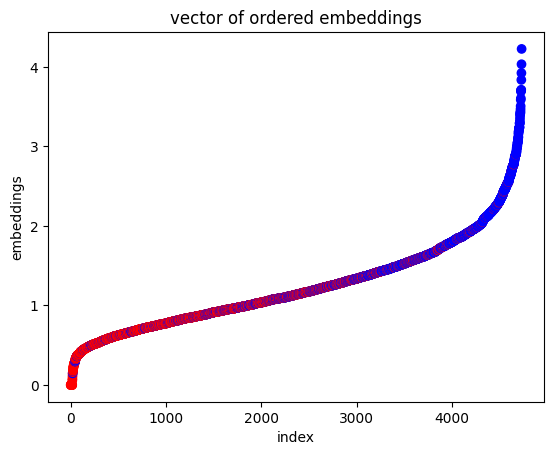

In [ ]:
import matplotlib.pyplot as plt

sorted_indices = np.argsort(embeddings)
sorted_embeddings = embeddings[sorted_indices]
sorted_labels = binary_labels[sorted_indices]

# ployying
colors = ['r' if label == 1 else 'b' for label in sorted_labels]
plt.scatter(range(len(sorted_embeddings)), sorted_embeddings, c=colors, marker='o')
plt.xlabel('index')
plt.ylabel('embeddings')
plt.title('vector of ordered embeddings')
plt.show()


### Logistic Regression

Finally we train the logistic regression model

In [ ]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000).fit(embeddings.reshape(-1,1), binary_labels)

Visualize Logistic regression function

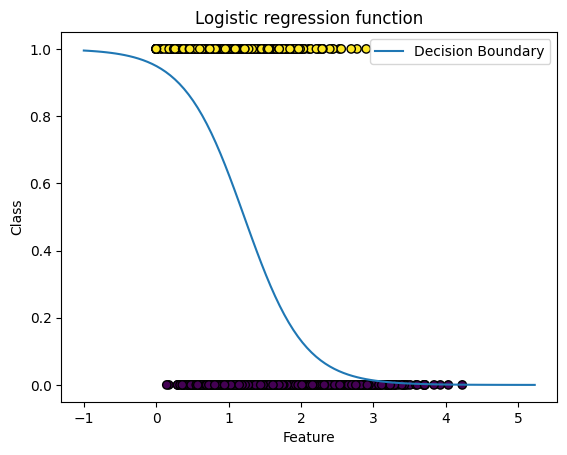

In [ ]:
x_min, x_max = embeddings.min() - 1, embeddings.max() + 1

xx = np.linspace(x_min, x_max, 100)
XX = np.c_[xx]
probs = lr_model.predict_proba(XX)[:, 1]

# plotting decision boundary
plt.plot(xx, probs, label='Decision Boundary')
plt.scatter(embeddings, binary_labels, c=binary_labels, edgecolors='k')
plt.xlabel('Feature')
plt.ylabel('Class')
plt.title('Logistic regression function')
plt.legend()
plt.show()

#### Compute training and test errors

About the training error:

Accuracy: 0.7142554991539763


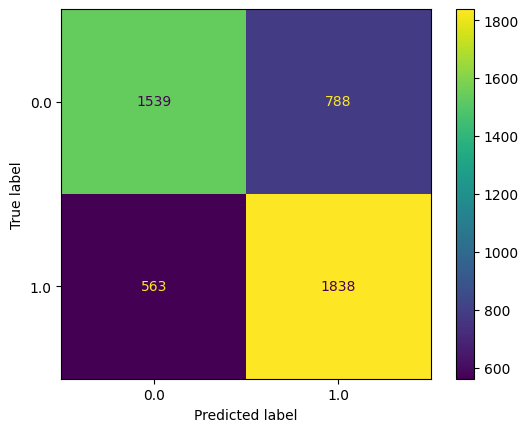

In [ ]:
pred_y = lr_model.predict(embeddings_reshaped)

from sklearn.metrics import accuracy_score

print(f'Accuracy: {accuracy_score(binary_labels, pred_y)}')

import matplotlib.pyplot as plt  
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(lr_model, embeddings_reshaped, binary_labels, values_format='d')  
plt.show() 

Extract and preprocess test sentences

In [ ]:
test_x1=pre_process(df_test[5])
test_x2=pre_process(df_test[6])

Extract and binarize test labels

In [ ]:
labels_test=list(df_test[4])

threshold_test=0.5

l_test=int(len(labels_test))
binary_labels_test=np.zeros(np.shape(labels_test))
for i in range(l_test):
  binary_labels_test[i] = 1 if labels_test[i] >= threshold_test else 0

Compute and print accuracy score and confusion matrix

Accuracy: 0.6816533720087019


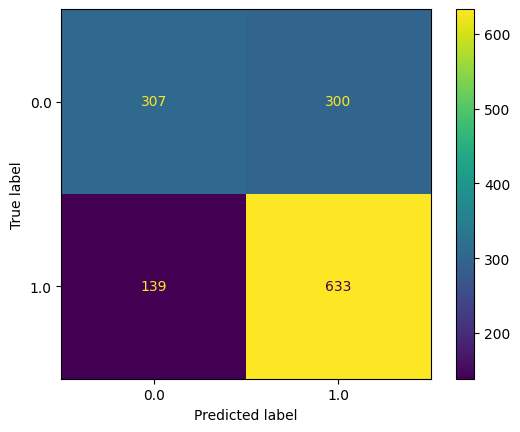

In [ ]:
test_x_vector1 = vectorize(test_x1)
test_x_vector2 = vectorize(test_x2)

# embeddings_test=np.concatenate((test_x_vector1,test_x_vector2), axis=1)
# embeddings_test=test_x_vector1-test_x_vector2

embeddings_test=(np.linalg.norm(test_x_vector1-test_x_vector2,axis=1)).reshape(-1,1)

pred_y = lr_model.predict(embeddings_test)

print(f'Accuracy: {accuracy_score(binary_labels_test, pred_y)}')

import matplotlib.pyplot as plt  
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(lr_model, embeddings_test, binary_labels_test, values_format='d')  
plt.show() 

### Support Vector Machine

We try here to use a Support Vector Machine model with radial basis function hoping that a non-linear based model could predict better our classification

In [ ]:
from sklearn.svm import SVC

embeddings_vector=embeddings_mean1-embeddings_mean2

x=embeddings_vector
y = binary_labels

# creating and training SVM model with RBF
svm_model = SVC(kernel='rbf')
svm_model.fit(x, y)


SVC()

Computing accuracy and confusion matrix for the new SVM model

Accuracy: 0.7026831036983321


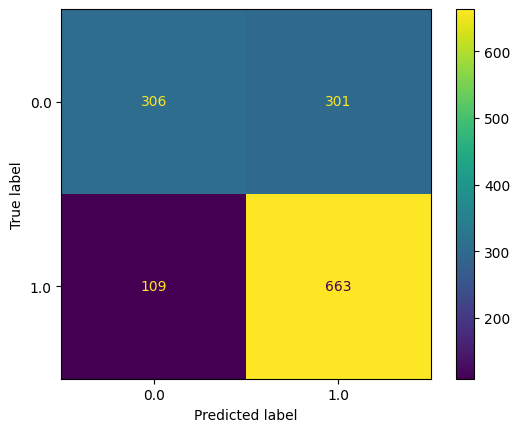

In [ ]:
embeddings_test_vector=test_x_vector1-test_x_vector2
pred_y = svm_model.predict(embeddings_test_vector)

print(f'Accuracy: {accuracy_score(binary_labels_test, pred_y)}')

import matplotlib.pyplot as plt  
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(svm_model, embeddings_test_vector, binary_labels_test, values_format='d')  
plt.show() 

## Transformers for regression task

To compute text embeddings now we start exploiting the transformer architecture.
This is the state-of-the-art sentence, text and image embeddings.

In [ ]:
pip install sentence-transformers

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.0/86.0 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 72.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 79.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 26.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 117.8 MB/s eta 0:00:00
  Created wheel for sentence-transformers: filename=sentence_transformers-2.2.2-py3-none-any.whl size=125926 sha256=da3b7089f9ca3ea401137ead754919cceecac5f005bb7c613cc34d7bf12f3416
  Stored in directory: /root/.cache/pip/wheels/62/f2/10/1e606fd5f02395388f74e7462910fe851042f97238cbbd902f
Successfully built sentence-transformers


For the first models we rely on SentenceTransformer library.

### Bi-encoder

The first architecture that we used is the Bi-Encoder

For each sentence pair, we pass to a BERT independently the sentences A and B which yields the embeddings u und v. The similarity of these embeddings is computed using cosine similarity and the result is compared to the gold similarity score. 

The training in a siamese network structure is done automatically when we use CosineSimilarityLoss.

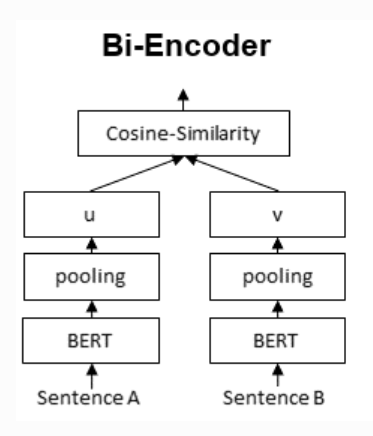

#### Import useful libraries and data

In [ ]:
from torch.utils.data import DataLoader
import math
from sentence_transformers import SentenceTransformer, LoggingHandler, losses, util, InputExample
from sentence_transformers.evaluation import EmbeddingSimilarityEvaluator
import logging
from datetime import datetime
import os
import gzip
import csv

In [ ]:
sts_dataset_path = 'datasets/stsbenchmark.tsv.gz'

#### Train the model

Model choice

In [ ]:
model_name = 'nli-distilroberta-base-v2'
train_batch_size = 16
num_epochs = 4

In [ ]:
model = SentenceTransformer(model_name)

Convert the dataset to a DataLoader ready for training

In [ ]:
train_samples = []
dev_samples = []
test_samples = []
with gzip.open(sts_dataset_path, 'rt', encoding='utf8') as fIn:
    reader = csv.DictReader(fIn, delimiter='\t', quoting=csv.QUOTE_NONE)
    for row in reader:
        score = float(row['score']) / 5.0                                 # Normalize score to range 0 ... 1
        inp_example = InputExample(texts=[row['sentence1'], row['sentence2']], label=score)

        if row['split'] == 'dev':
            dev_samples.append(inp_example)
        elif row['split'] == 'test':
            test_samples.append(inp_example)
        else:
            train_samples.append(inp_example)

Each InputExample contains the sentence pair together with the label (score) that ranges between 0 - 1.

In [ ]:
train_dataloader = DataLoader(train_samples, shuffle=True, batch_size=train_batch_size)

warmup_steps = math.ceil(len(train_dataloader) * num_epochs * 0.1)              #10% of train data for warm-up

As train loss we use CosineSimilarityLoss that trains the network with a siamese network structure 

In [ ]:
train_loss = losses.CosineSimilarityLoss(model=model)

As evaluator we use EmbeddingSimilarityEvaluator that evaluates a model based on the similarity of the embeddings by calculating the Spearman correlation in comparison to the gold standard labels.
  

In [ ]:
evaluator = EmbeddingSimilarityEvaluator.from_input_examples(dev_samples, name='sts-dev')

In [ ]:
model.fit(train_objectives=[(train_dataloader, train_loss)],
          evaluator=evaluator,
          epochs=num_epochs,
          evaluation_steps=1000,
          warmup_steps=warmup_steps,
          )

Epoch:   0%|          | 0/4 [00:00<?, ?it/s]

Iteration:   0%|          | 0/360 [00:00<?, ?it/s]

Iteration:   0%|          | 0/360 [00:00<?, ?it/s]

Iteration:   0%|          | 0/360 [00:00<?, ?it/s]

Iteration:   0%|          | 0/360 [00:00<?, ?it/s]

#### Make prediction on the test set

In [ ]:
from sentence_transformers import util
import pandas as pd
import torch

In [ ]:
x_test_1 = df_test[5]
x_test_2 = df_test[6]
x_test_1 = list(x_test_1)
x_test_2 = list(x_test_2)

label=df_test[4]/5.0
df_test[4]=label

Compute embedding for both lists of sentences

We pass the convert_to_tensor=True parameter to the encode function. This will return a pytorch tensor containing our embeddings. Then we call util.cos_sim(A, B) which computes the cosine similarity between all vectors in A and all vectors in B.

It returns a matrix with the respective cosine similarity scores for all possible pairs between embeddings1 and embeddings2.

In [ ]:
embeddings1 = model.encode(x_test_1, convert_to_tensor=True)
embeddings2 = model.encode(x_test_2, convert_to_tensor=True)

cosine_scores = util.cos_sim(embeddings1, embeddings2)

score1=torch.diagonal(cosine_scores)           #consider the elements on the diagonal

np_arr = score1.detach().cpu().numpy()

In [ ]:
df_test['bi-encoder']=np_arr
df_test

,0,1,2,3,4,5,6,TFIDF similarity,NegWMD similarity,bi-encoder
0,main-captions,MSRvid,2012test,24,0.50,A girl is styling her hair.,A girl is brushing her hair.,2.546968,-0.183398,0.779643
1,main-captions,MSRvid,2012test,33,0.72,A group of men play soccer on the beach.,A group of boys are playing soccer on the beach.,4.394012,-0.096329,0.834347
2,main-captions,MSRvid,2012test,45,1.00,One woman is measuring another woman's ankle.,A woman measures another woman's ankle.,4.574889,-0.040466,0.927879
3,main-captions,MSRvid,2012test,63,0.84,A man is cutting up a cucumber.,A man is slicing a cucumber.,3.576080,-0.153678,0.959536
4,main-captions,MSRvid,2012test,66,0.30,A man is playing a harp.,A man is playing a keyboard.,1.552567,-0.243498,0.354610
...,...,...,...,...,...,...,...,...,...,...
1374,main-news,headlines,2016,1354,0.00,"Philippines, Canada pledge to further boost re...",Philippines saves 100 after ferry sinks,1.028563,-0.255305,0.282006
1375,main-news,headlines,2016,1360,0.20,Israel bars Palestinians from Jerusalem's Old ...,"Two-state solution between Palestinians, Israe...",1.483183,-0.175882,0.214577
1376,main-news,headlines,2016,1368,0.20,How much do you know about Secret Service?,Lawmakers from both sides express outrage at S...,1.933940,-0.206747,0.179129
1377,main-news,headlines,2016,1420,0.00,Obama Struggles to Soothe Saudi Fears As Iran ...,Myanmar Struggles to Finalize Voter Lists for ...,0.000000,-0.164149,0.135025


#### Evaluate the model on the test set

In [ ]:
test_evaluator = EmbeddingSimilarityEvaluator.from_input_examples(test_samples, name='sts-test')
test_evaluator(model)

0.8652634617964167

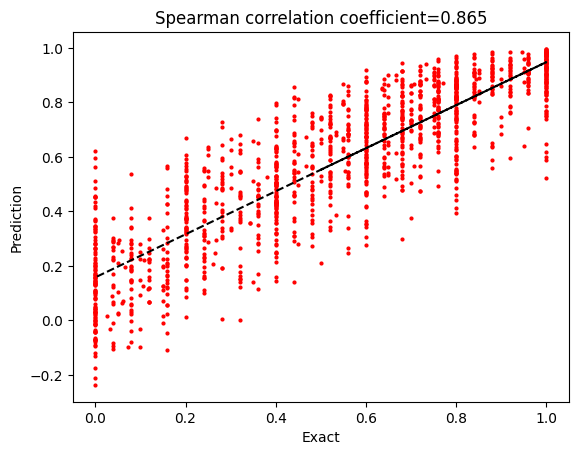

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
  
plt.plot(label, np_arr, 'or', markersize=2)
#plt.axis([0, 5, 0, 5])
plt.xlabel('Exact')
plt.ylabel('Prediction')
plt.title('Spearman correlation coefficient=0.865')

[m,q]=np.polyfit(label, np_arr,1)
plt.plot(label, m*label+q, '--k')

plt.show()


Compute the average error

In [ ]:
label= df_test[4]

In [ ]:
avg_error = sum( abs(label-np_arr) )
avg_error = avg_error/len(label)

print(avg_error)

0.12586189820667223


Compute also the Pearson correlation

In [ ]:
import scipy

pearson_correlation = scipy.stats.pearsonr(np_arr, label)
print('Pearson correlation coefficient = {0}\np-value = {1}'.format(
    pearson_correlation[0], pearson_correlation[1]))

Pearson correlation coefficient = 0.8644064838259167
p-value = 0.0


Very good result!

### Cross-encoder 1

The second architecture that we used is the Cross-Encoder. 

 For a Cross-Encoder, we pass both sentences simultaneously to the Transformer network. It produces than an output value  indicating the similarity of the input sentence pair.

 Differently from the bi-encoder it does not produce a sentence embedding

#### Import useful libraries and data

In [ ]:
sts_dataset_path = 'datasets/stsbenchmark.tsv.gz'

In [ ]:
from torch.utils.data import DataLoader
from sentence_transformers import LoggingHandler, util
from sentence_transformers.cross_encoder import CrossEncoder
from sentence_transformers.cross_encoder.evaluation import CERerankingEvaluator
from sentence_transformers import InputExample
import logging
from datetime import datetime
import gzip
import os
import tarfile
import tqdm

In [ ]:
model_name='distilroberta-base'

In [ ]:
train_batch_size = 32
num_epochs = 4

Since we are dealing with a continious scores, we set num_labels=1

In [ ]:
model = CrossEncoder(model_name, num_labels=1)

Convert the dataset to a DataLoader ready for training


In [ ]:
from sentence_transformers.cross_encoder.evaluation import CECorrelationEvaluator

In [ ]:
train_samples = []
dev_samples = []
test_samples = []
with gzip.open(sts_dataset_path, 'rt', encoding='utf8') as fIn:
    reader = csv.DictReader(fIn, delimiter='\t', quoting=csv.QUOTE_NONE)
    for row in reader:
        score = float(row['score']) / 5.0  # Normalize score to range 0 ... 1

        if row['split'] == 'dev':
            dev_samples.append(InputExample(texts=[row['sentence1'], row['sentence2']], label=score))
        elif row['split'] == 'test':
            test_samples.append(InputExample(texts=[row['sentence1'], row['sentence2']], label=score))
        else:
            #As we want to get symmetric scores, i.e. CrossEncoder(A,B) = CrossEncoder(B,A), we pass both combinations to the train set
            train_samples.append(InputExample(texts=[row['sentence1'], row['sentence2']], label=score))
            train_samples.append(InputExample(texts=[row['sentence2'], row['sentence1']], label=score))


# We wrap train_samples (which is a List[InputExample]) into a pytorch DataLoader
train_dataloader = DataLoader(train_samples, shuffle=True, batch_size=train_batch_size)


Add an evaluator, which evaluates the performance during training

In [ ]:
evaluator = CECorrelationEvaluator.from_input_examples(dev_samples, name='sts-dev')

#### Train the model

In [ ]:
warmup_steps = math.ceil(len(train_dataloader) * num_epochs * 0.1) #10% of train data for warm-up

# Train the model
model.fit(train_dataloader=train_dataloader,
          evaluator=evaluator,
          epochs=num_epochs,
          warmup_steps=warmup_steps)

Epoch:   0%|          | 0/4 [00:00<?, ?it/s]

Iteration:   0%|          | 0/360 [00:00<?, ?it/s]

Iteration:   0%|          | 0/360 [00:00<?, ?it/s]

Iteration:   0%|          | 0/360 [00:00<?, ?it/s]

Iteration:   0%|          | 0/360 [00:00<?, ?it/s]

Compute predictions on the test set

In [ ]:
x_test_1 = df_test[5]
x_test_2 = df_test[6]
x_test_1 = tuple(x_test_1)
x_test_2 = tuple(x_test_2)

x_test = []
for i in range(len(x_test_1)):
  x_test.append( (x_test_1[i], x_test_2[i]) )

y_test = df_test[4].values

In [ ]:
scores = model.predict(x_test)

In [ ]:
df_test['cross-encoder 1']=scores
df_test

,0,1,2,3,4,5,6,TFIDF similarity,NegWMD similarity,bi-encoder,cross-encoder 1
0,main-captions,MSRvid,2012test,24,0.50,A girl is styling her hair.,A girl is brushing her hair.,2.546968,-0.183398,0.779643,0.944169
1,main-captions,MSRvid,2012test,33,0.72,A group of men play soccer on the beach.,A group of boys are playing soccer on the beach.,4.394012,-0.096329,0.834347,0.818044
2,main-captions,MSRvid,2012test,45,1.00,One woman is measuring another woman's ankle.,A woman measures another woman's ankle.,4.574889,-0.040466,0.927879,0.953524
3,main-captions,MSRvid,2012test,63,0.84,A man is cutting up a cucumber.,A man is slicing a cucumber.,3.576080,-0.153678,0.959536,0.965081
4,main-captions,MSRvid,2012test,66,0.30,A man is playing a harp.,A man is playing a keyboard.,1.552567,-0.243498,0.354610,0.360440
...,...,...,...,...,...,...,...,...,...,...,...
1374,main-news,headlines,2016,1354,0.00,"Philippines, Canada pledge to further boost re...",Philippines saves 100 after ferry sinks,1.028563,-0.255305,0.282006,0.225631
1375,main-news,headlines,2016,1360,0.20,Israel bars Palestinians from Jerusalem's Old ...,"Two-state solution between Palestinians, Israe...",1.483183,-0.175882,0.214577,0.247849
1376,main-news,headlines,2016,1368,0.20,How much do you know about Secret Service?,Lawmakers from both sides express outrage at S...,1.933940,-0.206747,0.179129,0.195677
1377,main-news,headlines,2016,1420,0.00,Obama Struggles to Soothe Saudi Fears As Iran ...,Myanmar Struggles to Finalize Voter Lists for ...,0.000000,-0.164149,0.135025,0.029540


#### Evaluate the results

The CECorrelationEvaluator, given sentence pairs and continuous scores, computes the spearman correlation between the predicted score for the sentence pair and the gold score.

In [ ]:
evaluator = CECorrelationEvaluator.from_input_examples(test_samples, name='sts-test')
evaluator(model)

0.8445315821910232

We plot the correlations between the actual similarity_score and the predicted similarity.

Text(0.5, 1.0, 'Spearman correlation coefficient=0.844')

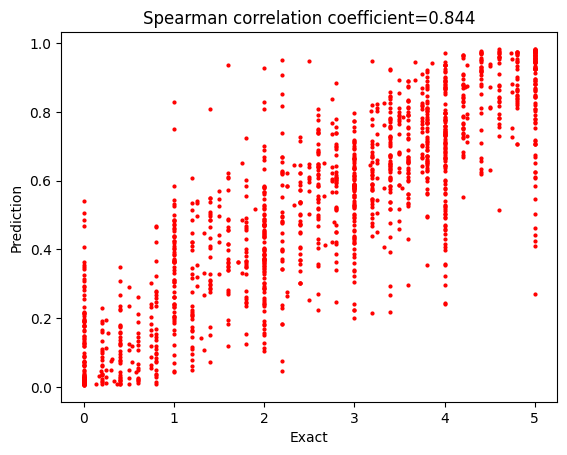

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
  
plt.plot(y_test, scores, 'or', markersize=2)
#plt.axis([0, 5, 0, 5])
plt.xlabel('Exact')
plt.ylabel('Prediction')
plt.title('Spearman correlation coefficient=0.844')

[m,q]=np.polyfit(y_test, scores,1)

plt.plot(y_test, m*y_test+q, '--k')


Compute the average error

In [ ]:
avg_error = sum( abs(label-scores) )
avg_error = avg_error/len(label)

print(avg_error)


0.11758712592640856


Compute also the Pearson correlation

In [ ]:
import scipy

pearson_correlation = scipy.stats.pearsonr(scores, label)
print('Pearson correlation coefficient = {0}\np-value = {1}'.format(
    pearson_correlation[0], pearson_correlation[1]))

Pearson correlation coefficient = 0.8560864102226509
p-value = 0.0


very good results!

### Cross-encoder 2

Let's try with another pre-trained model

#### Train the model

In [ ]:
model_name2 = 'roberta-large'
train_batch_size = 16
num_epochs = 4

In [ ]:
model2 = CrossEncoder('roberta-large', num_labels=1)

Some weights of the model checkpoint at roberta-large were not used when initializing RobertaForSequenceClassification: ['lm_head.layer_norm.weight', 'lm_head.layer_norm.bias', 'lm_head.bias', 'roberta.pooler.dense.bias', 'lm_head.dense.bias', 'roberta.pooler.dense.weight', 'lm_head.decoder.weight', 'lm_head.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-large and are newly initialized: ['classifier.dense.bias', 'classifie

In [ ]:
train_samples = []
dev_samples = []
test_samples = []
with gzip.open(sts_dataset_path, 'rt', encoding='utf8') as fIn:
    reader = csv.DictReader(fIn, delimiter='\t', quoting=csv.QUOTE_NONE)
    for row in reader:
        score = float(row['score']) / 5.0  # Normalize score to range 0 ... 1

        if row['split'] == 'dev':
            dev_samples.append(InputExample(texts=[row['sentence1'], row['sentence2']], label=score))
        elif row['split'] == 'test':
            test_samples.append(InputExample(texts=[row['sentence1'], row['sentence2']], label=score))
        else:
            #As we want to get symmetric scores, i.e. CrossEncoder(A,B) = CrossEncoder(B,A), we pass both combinations to the train set
            train_samples.append(InputExample(texts=[row['sentence1'], row['sentence2']], label=score))
            train_samples.append(InputExample(texts=[row['sentence2'], row['sentence1']], label=score))


# We wrap train_samples (which is a List[InputExample]) into a pytorch DataLoader
train_dataloader2 = DataLoader(train_samples, shuffle=True, batch_size=train_batch_size)


Use the same evaluator as before

In [ ]:
evaluator2 = CECorrelationEvaluator.from_input_examples(dev_samples, name='sts-dev')

In [ ]:
warmup_steps = math.ceil(len(train_dataloader2) * num_epochs * 0.1) #10% of train data for warm-up

# Train the model
model2.fit(train_dataloader=train_dataloader2,
          evaluator=evaluator2,
          epochs=num_epochs,
          warmup_steps=warmup_steps)

Epoch:   0%|          | 0/4 [00:00<?, ?it/s]

Iteration:   0%|          | 0/719 [00:00<?, ?it/s]

Iteration:   0%|          | 0/719 [00:00<?, ?it/s]

Iteration:   0%|          | 0/719 [00:00<?, ?it/s]

Iteration:   0%|          | 0/719 [00:00<?, ?it/s]

#### Compute predictions on the test set

In [ ]:
x_test_1 = df_test[5]
x_test_2 = df_test[6]
x_test_1 = tuple(x_test_1)
x_test_2 = tuple(x_test_2)

x_test = []
for i in range(len(x_test_1)):
  x_test.append( (x_test_1[i], x_test_2[i]) )

y_test = df_test[4].values

In [ ]:
scores2 = model2.predict(x_test)

In [ ]:
df_test['cross-encoder 2']=scores2
df_test

#### Evaluate the model

In [ ]:
evaluator = CECorrelationEvaluator.from_input_examples(test_samples, name='sts-test')
evaluator(model2)

0.9077244729963432

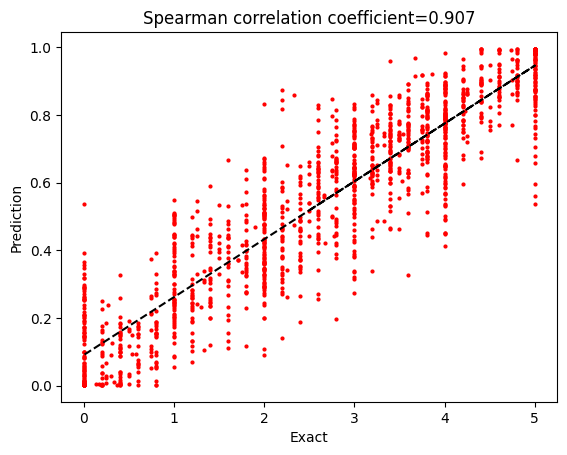

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
  
plt.plot(y_test, scores2, 'or', markersize=2)
#plt.axis([0, 5, 0, 5])
plt.xlabel('Exact')
plt.ylabel('Prediction')
plt.title('Spearman correlation coefficient=0.907')

[m,q]=np.polyfit(y_test, scores2,1)
plt.plot(y_test, m*y_test+q, '--k')

plt.show()

In [ ]:
avg_error = sum( abs(label-scores2) )
avg_error = avg_error/len(label)

print(avg_error)

0.09375447040290259


In [ ]:
import scipy

pearson_correlation = scipy.stats.pearsonr(scores2, label)
print('Pearson correlation coefficient = {0}\np-value = {1}'.format(
    pearson_correlation[0], pearson_correlation[1]))

Pearson correlation coefficient = 0.9128533513264175
p-value = 0.0


Our best result!

### Save (temporary)

In [ ]:
df_test.to_csv("TEMP_trans_test_with_predictions.csv")

### Try with a different library...ktrain

Follow the strategy seen during Labs for classification using ktrain (but exploit the capability of performing regression here)

In [ ]:
!pip install ktrain

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.3/25.3 MB 46.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 43.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 653.6/653.6 kB 25.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 468.8/468.8 kB 41.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Created wheel for ktrain: filename=ktrain-0.37.0-py3-none-any.whl size=25320561 sha

Import the dataset in the correct format

In [ ]:
x_train = df_train[[5, 6]].values
x_train = list(map(tuple, x_train))

y_train = df_train[4].values            # labels

In [ ]:
x_validation = df_val[[5, 6]].values
x_validation = list(map(tuple, x_validation))

y_validation = df_val[4].values

Import a pretrained version of BERT

In [ ]:
import ktrain
from ktrain import text

1.   Load the model (e.g. 'distilbert-base-uncased', 'bert-base-uncased')

In [ ]:
MODEL_NAME = 'bert-base-uncased'
transformer = text.Transformer(MODEL_NAME, maxlen=128)

2. Process the training/test data

In [ ]:
processed_train = transformer.preprocess_train(x_train, y_train)
processed_validation = transformer.preprocess_test(x_validation, y_validation)

preprocessing train...
language: en
sentence pairs detected


/usr/local/lib/python3.10/dist-packages/ktrain/utils.py:727: UserWarning: Task is being treated as REGRESSION because either class_names argument was not supplied or is_regression=True. If this is incorrect, change accordingly.
  warnings.warn(


preprocessing test...
language: en
sentence pairs detected


3. Create a model and learner

In [ ]:
model = transformer.get_regression_model()
learner = ktrain.get_learner(model, train_data=processed_train, val_data=processed_validation, batch_size=32)

4.   Train the model

In [ ]:
learner.fit_onecycle(5e-5, 4)



begin training using onecycle policy with max lr of 5e-05...
Epoch 1/4
180/180 [==============================] - 179s 852ms/step - loss: 2.3208 - mae: 1.1698 - val_loss: 0.7387 - val_mae: 0.6784
Epoch 2/4
180/180 [==============================] - 153s 853ms/step - loss: 0.6243 - mae: 0.6160 - val_loss: 0.6098 - val_mae: 0.5866
Epoch 3/4
180/180 [==============================] - 154s 856ms/step - loss: 0.3549 - mae: 0.4646 - val_loss: 0.5511 - val_mae: 0.5759
Epoch 4/4
180/180 [==============================] - 154s 855ms/step - loss: 0.1979 - mae: 0.3423 - val_loss: 0.5383 - val_mae: 0.5511


5.   Evaluate the model

In [ ]:
learner.validate()

47/47 [==============================] - 16s 207ms/step


[('mae', 0.5510915)]

6.   Make some predictions with it

In [ ]:
x_test = df_test[[5, 6]].values
x_test = list(map(tuple, x_test))

y_test = df_test[4].values

In [ ]:
scores = []
predictor = ktrain.get_predictor(learner.model, preproc=transformer)

for i in range(len(x_test)):
  pred = predictor.predict((x_test[i][0], x_test[i][1]))
  scores.append(pred)

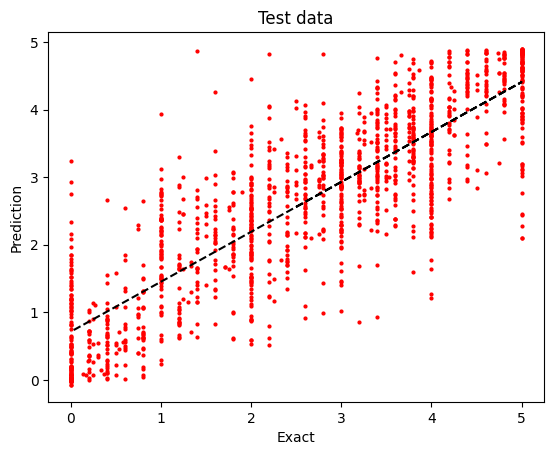

0.7391861744652399 0.7124519820441799


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
  
plt.plot(y_test, scores, 'or', markersize=2)
#plt.axis([0, 5, 0, 5])
plt.xlabel('Exact')
plt.ylabel('Prediction')
plt.title('Test data')

[m,q]=np.polyfit(y_test, scores,1)
plt.plot(y_test, m*y_test+q, '--k')

plt.show()

print(m, q)

In [ ]:
avg_error = sum( abs(y_test-scores) )
avg_error = avg_error/len(y_test)

print(avg_error)

0.6101159681123438


In [ ]:
predictor.save('/tmp/model_train_1')

#p = ktrain.load_predictor('/tmp/model_ktrain_1')

In [ ]:
import scipy

pearson_correlation = scipy.stats.pearsonr(scores, y_test)
print('Pearson correlation coefficient = {0}\np-value = {1}'.format(
    pearson_correlation[0], pearson_correlation[1]))

Pearson correlation coefficient = 0.8463845220932084
p-value = 0.0


Very good results also here.

In [ ]:
df_test['regression_ktrain']=scores
df_test

,0,1,2,3,4,5,6,regression_ktrain
0,main-captions,MSRvid,2012test,24,2.5,A girl is styling her hair.,A girl is brushing her hair.,4.019412
1,main-captions,MSRvid,2012test,33,3.6,A group of men play soccer on the beach.,A group of boys are playing soccer on the beach.,4.212562
2,main-captions,MSRvid,2012test,45,5.0,One woman is measuring another woman's ankle.,A woman measures another woman's ankle.,4.785541
3,main-captions,MSRvid,2012test,63,4.2,A man is cutting up a cucumber.,A man is slicing a cucumber.,4.833124
4,main-captions,MSRvid,2012test,66,1.5,A man is playing a harp.,A man is playing a keyboard.,2.131255
...,...,...,...,...,...,...,...,...
1374,main-news,headlines,2016,1354,0.0,"Philippines, Canada pledge to further boost re...",Philippines saves 100 after ferry sinks,1.086582
1375,main-news,headlines,2016,1360,1.0,Israel bars Palestinians from Jerusalem's Old ...,"Two-state solution between Palestinians, Israe...",1.489657
1376,main-news,headlines,2016,1368,1.0,How much do you know about Secret Service?,Lawmakers from both sides express outrage at S...,1.432360
1377,main-news,headlines,2016,1420,0.0,Obama Struggles to Soothe Saudi Fears As Iran ...,Myanmar Struggles to Finalize Voter Lists for ...,0.445774


### Cross-encoder...with ChatGPT

The best results we noticed were returned by fine-tuning a Cross-Encoder with BERT (or similar). We were curious whether chatGPT was able to design a different and effective model for our task, so we tried to ask chatGPT for a code able to fine-tune a cross-encoder for STS data. With some manual adjustements its code works and returns good results!

In [ ]:
import torch
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AdamW

#### Build and train the model

Step 1: Prepare your dataset

Assuming you have your sentence pairs and similarity scores stored in two lists: sentences1 and sentences2, scores

- sentences1 = ["I like cats", "The sun is shining", "I ate an apple"]
- sentences2 = ["I love cats", "It's a sunny day", "I had a banana"]
- scores = [4.5, 2.3, 3.8]

In [ ]:
x_train_1 = df_train[5]
x_train_2 = df_train[6]
x_train_1 = list(x_train_1)
x_train_2 = list(x_train_2)

y_train = df_train[4].values
y_train = y_train/5.0

In [ ]:
x_validation_1 = df_val[5]
x_validation_2 = df_val[6]
x_validation_1 = list(x_validation_1)
x_validation_2 = list(x_validation_2)

y_validation = df_val[4].values
y_validation = y_validation/5.0

Step 2: Load the pre-trained model

In [ ]:
model_name = "cross-encoder/stsb-distilroberta-base"
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=1)

Step 3: Tokenization

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenized_x_train = tokenizer(x_train_1, x_train_2, padding=True, truncation=True, return_tensors="pt")

tokenized_x_val = tokenizer(x_validation_1, x_validation_2, padding=True, truncation=True, return_tensors="pt")

Step 4: Data preparation

In [ ]:
train_input_ids = tokenized_x_train["input_ids"]
train_attention_mask = tokenized_x_train["attention_mask"]
train_labels = torch.tensor(y_train).unsqueeze(1)  # Convert scores to tensor and reshape to match model's output

val_input_ids = tokenized_x_val["input_ids"]
val_attention_mask = tokenized_x_val["attention_mask"]
val_labels = torch.tensor(y_validation).unsqueeze(1)  # Convert scores to tensor and reshape to match model's output

Step 5: Create data loaders

In [ ]:
batch_size = 8
train_dataset = torch.utils.data.TensorDataset(train_input_ids, train_attention_mask, train_labels)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataset = torch.utils.data.TensorDataset(val_input_ids, val_attention_mask, val_labels)
val_loader = DataLoader(val_dataset, batch_size=batch_size)

Step 6: Define training parameters

In [ ]:
learning_rate = 2e-5
num_epochs = 3

Step 7: Training loop

In [ ]:
model = model.double()
optimizer = AdamW(model.parameters(), lr=learning_rate)

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for batch in train_loader:
        batch = tuple(t.to(device) for t in batch)
        input_ids, attention_mask, labels = batch

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        total_loss += loss.item()

        loss.backward()
        optimizer.step()

    average_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1} - Average Loss: {average_loss}")

    # Step 10: Validation
    model.eval()
    total_val_loss = 0

    with torch.no_grad():
        for val_batch in val_loader:
            val_batch = tuple(t.to(device) for t in val_batch)
            val_input_ids, val_attention_mask, val_labels = val_batch

            val_outputs = model(val_input_ids, attention_mask=val_attention_mask, labels=val_labels)
            val_loss = val_outputs.loss
            total_val_loss += val_loss.item()

    average_val_loss = total_val_loss / len(val_loader)
    print(f"Epoch {epoch+1} - Validation Loss: {average_val_loss}")

/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:407: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Epoch 1 - Average Loss: 0.19936268453070055
Epoch 1 - Validation Loss: 0.47394940161645027
Epoch 2 - Average Loss: 0.13566585473959653
Epoch 2 - Validation Loss: 0.4404371642875695
Epoch 3 - Average Loss: 0.11660830737470555
Epoch 3 - Validation Loss: 0.44649849389787183


Step 8: Model saving

In [ ]:
save_directory = "./fine-tuned-model-chat-gpt"
model.save_pretrained(save_directory)
tokenizer.save_pretrained(save_directory)

('./fine-tuned-model-chat-gpt/tokenizer_config.json',
 './fine-tuned-model-chat-gpt/special_tokens_map.json',
 './fine-tuned-model-chat-gpt/vocab.json',
 './fine-tuned-model-chat-gpt/merges.txt',
 './fine-tuned-model-chat-gpt/added_tokens.json',
 './fine-tuned-model-chat-gpt/tokenizer.json')

In [ ]:
#Load the saved model
loaded_model = AutoModelForSequenceClassification.from_pretrained(save_directory)
loaded_model.to(device)

RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-5): 6 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (

#### Test the model

Step 9: make predictions

In [ ]:
x_test_1 = df_test[5]
x_test_2 = df_test[6]
x_test_1 = list(x_test_1)
x_test_2 = list(x_test_2)

y_test = df_test[4].values

For inference I need to adjust the batch size for limitation of GPU...

In [ ]:
from torch.utils.data import Dataset

class InferenceDataset(Dataset):
    def __init__(self, sentences1, sentences2):
        self.sentences1 = sentences1
        self.sentences2 = sentences2

    def __len__(self):
        return len(self.sentences1)

    def __getitem__(self, idx):
        return self.sentences1[idx], self.sentences2[idx]

In [ ]:
inference_dataset = InferenceDataset(x_test_1, x_test_2)

inference_loader = DataLoader(inference_dataset, batch_size=1)

In [ ]:
# Assuming you have the inference_loader and loaded_model set up as mentioned before
scores = []

# Set the model to evaluation mode
loaded_model.eval()

# Iterate over the inference data loader
for batch in inference_loader:
    # Extract the input tensors from the batch
    sentences1, sentences2 = batch

    # Tokenize the sentences
    tokenized_inputs = tokenizer(sentences1, sentences2, padding=True, truncation=True, return_tensors="pt")

    # Move the input tensors to the appropriate device (GPU if available)
    tokenized_inputs = {key: value.to(device) for key, value in tokenized_inputs.items()}

    # Perform the forward pass
    with torch.no_grad():
        outputs = loaded_model(**tokenized_inputs)

    # Get the predicted scores
    scores.append(outputs.logits.squeeze().tolist())

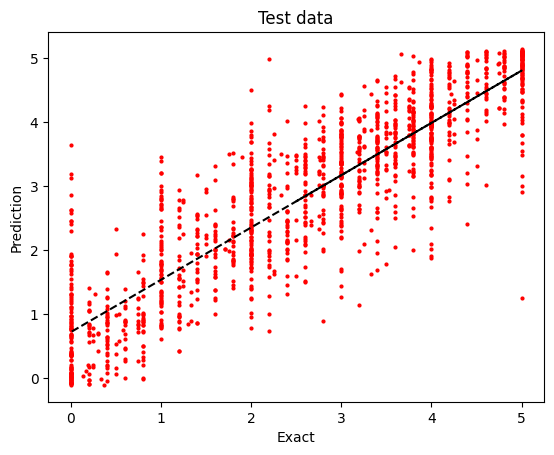

0.8173470303580758 0.7153537203447472


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
  
plt.plot(y_test, scores, 'or', markersize=2)
#plt.axis([0, 5, 0, 5])
plt.xlabel('Exact')
plt.ylabel('Prediction')
plt.title('Test data')

[m,q]=np.polyfit(y_test, scores,1)
plt.plot(y_test, m*y_test+q, '--k')

plt.show()

print(m, q)

In [ ]:
avg_error = sum( abs(y_test-scores) )
avg_error = avg_error/len(y_test)

print(avg_error)

0.5581701836421108


In [ ]:
import scipy

pearson_correlation = scipy.stats.pearsonr(scores, y_test)
print('Pearson correlation coefficient = {0}\np-value = {1}'.format(
    pearson_correlation[0], pearson_correlation[1]))

Pearson correlation coefficient = 0.8811929565070367
p-value = 0.0


In [ ]:
df_test['regression_chatGPT']=scores
df_test

,0,1,2,3,4,5,6,regression_ktrain,regression_chatGPT
0,main-captions,MSRvid,2012test,24,2.5,A girl is styling her hair.,A girl is brushing her hair.,4.019412,2.154089
1,main-captions,MSRvid,2012test,33,3.6,A group of men play soccer on the beach.,A group of boys are playing soccer on the beach.,4.212562,4.204353
2,main-captions,MSRvid,2012test,45,5.0,One woman is measuring another woman's ankle.,A woman measures another woman's ankle.,4.785541,4.983991
3,main-captions,MSRvid,2012test,63,4.2,A man is cutting up a cucumber.,A man is slicing a cucumber.,4.833124,4.811834
4,main-captions,MSRvid,2012test,66,1.5,A man is playing a harp.,A man is playing a keyboard.,2.131255,2.092705
...,...,...,...,...,...,...,...,...,...
1374,main-news,headlines,2016,1354,0.0,"Philippines, Canada pledge to further boost re...",Philippines saves 100 after ferry sinks,1.086582,1.114442
1375,main-news,headlines,2016,1360,1.0,Israel bars Palestinians from Jerusalem's Old ...,"Two-state solution between Palestinians, Israe...",1.489657,1.216195
1376,main-news,headlines,2016,1368,1.0,How much do you know about Secret Service?,Lawmakers from both sides express outrage at S...,1.432360,1.194979
1377,main-news,headlines,2016,1420,0.0,Obama Struggles to Soothe Saudi Fears As Iran ...,Myanmar Struggles to Finalize Voter Lists for ...,0.445774,0.283832


### Sequential Neural Network

The idea now is to first manually apply BERT (or similar) in order to get the sentence embedding and then use the embedding as the input of a standard sequential Neural Network for regression.

In [ ]:
!pip install -U sentence-transformers
!pip install datasets
!pip install hnswlib

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 474.6/474.6 kB 19.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.5/110.5 kB 15.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.5/212.5 kB 24.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.3/134.3 kB 16.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 62.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.5/114.5 kB 14.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.8/268.8 kB 27.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.6/149.6 kB 17.7 MB/s eta 0:00:00
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
  Installing build dependencies ... done
  Getting requir

In [ ]:
from sentence_transformers import SentenceTransformer, util
import torch

model = SentenceTransformer('all-mpnet-base-v2')

In [ ]:
x_train = df_train[[5,6]].values

y_train = df_train[4].values /5.0

Create the embeddings

In [ ]:
x_train_embeddings = model.encode(x_train)

len(x_train_embeddings[0])

768

In [ ]:
x_val = df_val[[5,6]].values

y_val = df_val[4].values /5.0

x_val_embeddings = model.encode(x_val)

#### Design the network

The model receives in input the embeddings of the two sentences, preprocessed above. Then it is composed by a sequence of Dense Layers and Dropout. We took inspiration from some models designed during the course of Artifical Neural Networks and Deep Learning, attended the previous year.

In [ ]:
import tensorflow as tf
import tensorflow.keras as tfk
import tensorflow.keras.layers as tfkl

seed = 42

In [ ]:
def build_dropout_model(input_shape, dropout_rate):
    tf.random.set_seed(seed)

    # Build the neural network layer by layer
    input_layer = tfkl.Input(shape=input_shape, name='Input')
    hidden_layer1 = tfkl.Dense(units=256, activation='relu', name='Hidden1', 
                               kernel_initializer=tfk.initializers.HeUniform(seed=seed))(input_layer)
    hidden_layer1 = tfkl.Dropout(dropout_rate, seed=seed)(hidden_layer1)
    hidden_layer2 = tfkl.Dense(units=128, activation='relu', name='Hidden2', 
                               kernel_initializer=tfk.initializers.HeUniform(seed=seed))(hidden_layer1)
    hidden_layer2 = tfkl.Dropout(dropout_rate, seed=seed)(hidden_layer2)
    hidden_layer3 = tfkl.Dense(units=64, activation='relu', name='Hidden3', 
                               kernel_initializer=tfk.initializers.HeUniform(seed=seed))(hidden_layer2)
    hidden_layer3 = tfkl.Dropout(dropout_rate, seed=seed)(hidden_layer3)
    output_layer = tfkl.Dense(units=1, activation='linear', name='Output', 
                              kernel_initializer=tfk.initializers.GlorotUniform(seed=seed))(hidden_layer3)

    # Connect input and output through the Model class
    network = tfk.Model(inputs=input_layer, outputs=output_layer, name='dropout_model')

    # Compile the model
    learning_rate = 1e-3
    opt = tfk.optimizers.Adam(learning_rate)
    loss = tfk.losses.MeanSquaredError()
    mtr = ['mse']
    network.compile(loss=loss, optimizer=opt, metrics=mtr)

    # Return the model
    return network

Model: "dropout_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 Input (InputLayer)          [(None, 768)]             0         
                                                                 
 Hidden1 (Dense)             (None, 256)               196864    
                                                                 
 dropout_152 (Dropout)       (None, 256)               0         
                                                                 
 Hidden2 (Dense)             (None, 128)               32896     
                                                                 
 dropout_153 (Dropout)       (None, 128)               0         
                                                                 
 Hidden3 (Dense)             (None, 64)                8256      
                                                                 
 dropout_154 (Dropout)       (None, 64)              

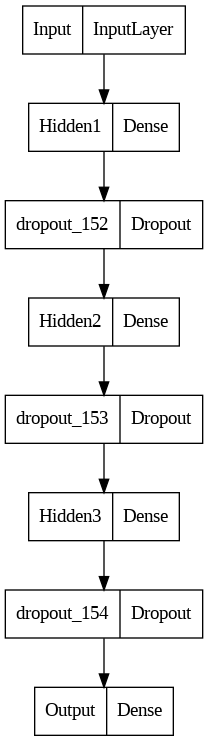

In [ ]:
dropout_rate = 0.3
input_shape = len(x_train_embeddings[0])    #768

network = build_dropout_model(input_shape, dropout_rate)
network.summary()
tfk.utils.plot_model(network)

#### Train the network

In [ ]:
patience = 150
early_stopping = tfk.callbacks.EarlyStopping(monitor='val_mse', mode='min', patience=patience, restore_best_weights=True)

batch_size = 256
epochs = 1000

Train the model (with Early Stopping)

In [ ]:
# Compile the model
#network.compile(loss='mse', optimizer='adam')

# Train the model
history_dropout = network.fit(
    x = x_train_embeddings,
    y = y_train, 
    validation_data=(x_val_embeddings, y_val),
    batch_size = batch_size,
    epochs = epochs,
    callbacks=[early_stopping]
).history

Epoch 1/1000
19/23 [=======================>......] - ETA: 0s - loss: 0.0076

23/23 [==============================] - 4s 16ms/step - loss: 0.0075 - val_loss: 0.0558
Epoch 2/1000
17/23 [=====================>........] - ETA: 0s - loss: 0.0069

23/23 [==============================] - 0s 11ms/step - loss: 0.0069 - val_loss: 0.0544
Epoch 3/1000
22/23 [===========================>..] - ETA: 0s - loss: 0.0064

23/23 [==============================] - 0s 16ms/step - loss: 0.0064 - val_loss: 0.0542
Epoch 4/1000
20/23 [=========================>....] - ETA: 0s - loss: 0.0062

23/23 [==============================] - 0s 14ms/step - loss: 0.0062 - val_loss: 0.0541
Epoch 5/1000
21/23 [==========================>...] - ETA: 0s - loss: 0.0062

...

23/23 [==============================] - 0s 10ms/step - loss: 0.0021 - val_loss: 0.0662
Epoch 997/1000
20/23 [=========================>....] - ETA: 0s - loss: 0.0021

23/23 [==============================] - 0s 10ms/step - loss: 0.0022 - val_loss: 0.0667
Epoch 998/1000
20/23 [=========================>....] - ETA: 0s - loss: 0.0024

23/23 [==============================] - 0s 10ms/step - loss: 0.0024 - val_loss: 0.0650
Epoch 999/1000
21/23 [==========================>...] - ETA: 0s - loss: 0.0022

23/23 [==============================] - 0s 9ms/step - loss: 0.0022 - val_loss: 0.0657
Epoch 1000/1000
20/23 [=========================>....] - ETA: 0s - loss: 0.0022

23/23 [==============================] - 0s 11ms/step - loss: 0.0022 - val_loss: 0.0660


In [ ]:
def monitor(histories, names, colors, early_stopping=1):
    assert len(histories) == len(names)
    assert len(histories) == len(colors)
    plt.figure(figsize=(15,6))
    for idx in range(len(histories)):
        plt.plot(histories[idx]['mse'][:-early_stopping], label=names[idx]+' Training', alpha=.4, color=colors[idx], linestyle='--')
        plt.plot(histories[idx]['val_mse'][:-early_stopping], label=names[idx]+' Validation', alpha=.8, color=colors[idx])   
    plt.ylim(0.0075, 0.02)
    plt.title('Mean Squared Error')
    plt.legend(bbox_to_anchor=(1,1))
    plt.grid(alpha=.3)
    plt.show()

In [ ]:
history_dropout

{'loss': [0.007487649563699961,
  0.006928012240678072,
  0.0064281318336725235,
  0.006226625759154558,
  0.006243196781724691,
  0.006155516020953655,
  0.005988097749650478,
  0.0061050476506352425,
  0.005653169471770525,
  0.005965406075119972,
  0.005559463053941727,
  0.005741958972066641,
  0.005602763965725899,
  0.005606004036962986,
  0.005571751389652491,
  0.005376226268708706,
  0.005447127856314182,
  0.005652495659887791,
  0.00556612852960825,
  0.005423256661742926,
  0.00525471568107605,
  0.005318370647728443,
  0.005202276166528463,
  0.0051330458372831345,
  0.005129988770931959,
  0.00496556656435132,
  0.005090240854769945,
  0.005063940770924091,
  0.005029527470469475,
  0.005132336635142565,
  0.004972286522388458,
  0.005167584866285324,
  0.005044672172516584,
  0.004856935236603022,
  0.004834376275539398,
  0.00486245471984148,
  0.004707701504230499,
  0.0048454320058226585,
  0.004548892378807068,
  0.00470479391515255,
  0.004677582532167435,
  0.00445

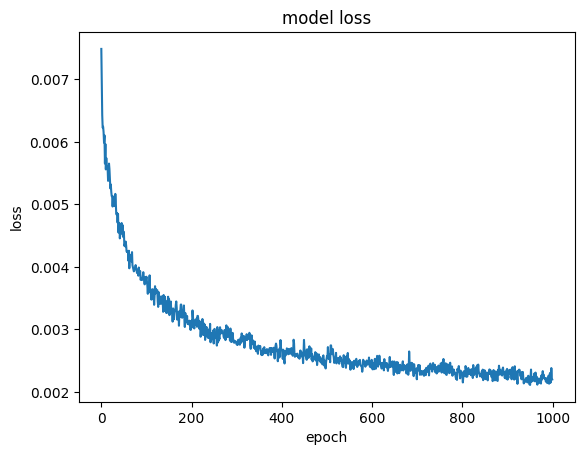

In [ ]:
import keras
from matplotlib import pyplot as plt

plt.plot(history_dropout['loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.show()

#### Test the model

In [ ]:
x_test = df_test[[5,6]].values
x_test = list(x_test)

y_test = df_test[4].values /5.0

In [ ]:
x_test_embeddings = model.encode(x_test)

In [ ]:
scores = network.predict(x_test_embeddings)

print(scores)

44/44 [==============================] - 0s 2ms/step
[[0.33824116]
 [0.85053396]
 [0.7195168 ]
 ...
 [0.51190937]
 [0.05207828]
 [0.6527504 ]]


In [ ]:
scores = scores.reshape(len(scores))

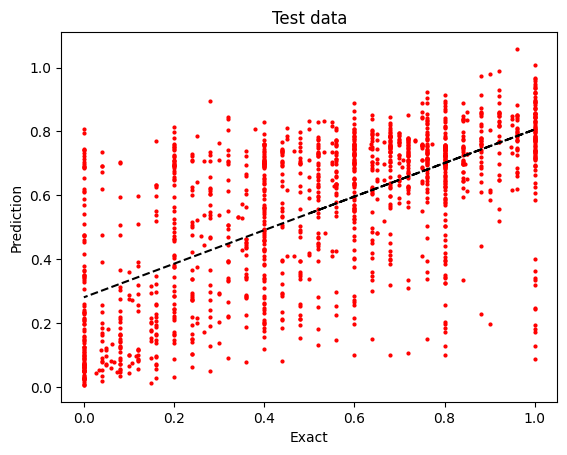

0.5254368548755445 0.2808506888541465


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
  
plt.plot(y_test, scores, 'or', markersize=2)
#plt.axis([0, 5, 0, 5])
plt.xlabel('Exact')
plt.ylabel('Prediction')
plt.title('Test data')

[m,q]=np.polyfit(y_test, scores,1)
plt.plot(y_test, m*y_test+q, '--k')

plt.show()

print(m, q)

In [ ]:
avg_error = sum( abs(y_test-scores) )
avg_error = avg_error/len(y_test)

print(avg_error)

0.17893800233171195


In [ ]:
import scipy

pearson_correlation = scipy.stats.pearsonr(scores, y_test)
print('Pearson correlation coefficient = {0}\np-value = {1}'.format(
    pearson_correlation[0], pearson_correlation[1]))

Pearson correlation coefficient = 0.6464097578623348
p-value = 5.626668646608615e-164


## Transformers for classification task

The STS task can be interpreted also as classification. In particular, we have to convert scores to binary values. 

### With SentenceTransformers...

 Setup


In [ ]:
pip install transformers

In [ ]:
import transformers
import numpy as np
import pandas as pd
import tensorflow as tf

In [ ]:
max_length = 56  # Maximum length of input sentence to the model.
batch_size = 32
epochs = 5

Preprocessing: for the classification task we create one-hot encode training, validation, and test labels



In [ ]:
treshold1 = 2.5

df_train["label"] = df_train[4].apply(
    lambda x: 1 if x >treshold1 else 0 
    #if x <treshold2 else 1
)

y_train = tf.keras.utils.to_categorical(df_train.label, num_classes=2)

In [ ]:
df_val["label"] = df_val[4].apply(
    lambda x: 1 if x >treshold1 else 0 
    #if x <treshold2 else 1
)

y_valid = tf.keras.utils.to_categorical(df_val.label, num_classes=2)

In [ ]:
df_test["label"] = df_test[4].apply(
    lambda x: 1 if x >treshold1 else 0 
    #if x <treshold2 else 1
)

y_test = tf.keras.utils.to_categorical(df_test.label, num_classes=2)

Target Distribution in the training set

In [ ]:
true = df_train.loc[df_train['label'] == 1]
false = df_train.loc[df_train['label'] == 0]
print(f"# similar sentence: {len(true)}")
print(f"# different sentence: {len(false)}")

# similar sentence: 3385
# different sentence: 2364


In [ ]:
from collections import Counter

counts = Counter(df_train['label'])
counts    

Counter({1: 3385, 0: 2364})

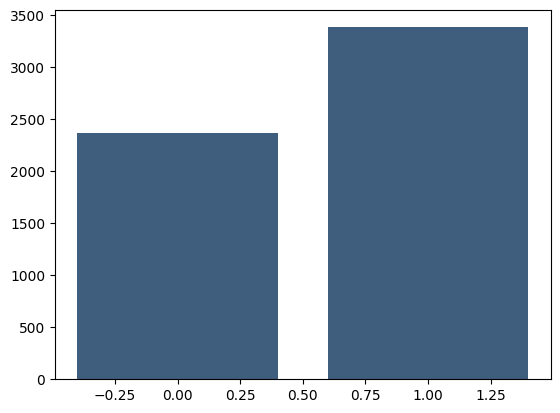

In [ ]:
import matplotlib.pyplot as plt

plt.bar(counts.keys(), counts.values(), color="#3F5D7D", width=0.8);

#### Build the model

Create a custom data generator

In [ ]:
class BertSemanticDataGenerator(tf.keras.utils.Sequence):
    """Generates batches of data.

    Args:
        sentence_pairs: Array of premise and hypothesis input sentences.
        labels: Array of labels.
        batch_size: Integer batch size.
        shuffle: boolean, whether to shuffle the data.
        include_targets: boolean, whether to incude the labels.

    Returns:
        Tuples `([input_ids, attention_mask, `token_type_ids], labels)`
        (or just `[input_ids, attention_mask, `token_type_ids]`
         if `include_targets=False`)
    """

    def __init__(
        self,
        sentence_pairs,
        labels,
        batch_size=batch_size,
        shuffle=True,
        include_targets=True,
    ):
        self.sentence_pairs = sentence_pairs
        self.labels = labels
        self.shuffle = shuffle
        self.batch_size = batch_size
        self.include_targets = include_targets
        # Load our BERT Tokenizer to encode the text.
        # We will use base-base-uncased pretrained model.
        self.tokenizer = transformers.BertTokenizer.from_pretrained(
            "bert-base-uncased", do_lower_case=True
        )
        self.indexes = np.arange(len(self.sentence_pairs))
        self.on_epoch_end()

    def __len__(self):
        # Denotes the number of batches per epoch.
        return len(self.sentence_pairs) // self.batch_size

    def __getitem__(self, idx):
        # Retrieves the batch of index.
        indexes = self.indexes[idx * self.batch_size : (idx + 1) * self.batch_size]
        sentence_pairs = self.sentence_pairs[indexes]

        # With BERT tokenizer's batch_encode_plus batch of both the sentences are
        # encoded together and separated by [SEP] token.
        encoded = self.tokenizer.batch_encode_plus(
            sentence_pairs.tolist(),
            add_special_tokens=True,
            max_length=max_length,
            return_attention_mask=True,
            return_token_type_ids=True,
            pad_to_max_length=True,
            return_tensors="tf",
        )

        # Convert batch of encoded features to numpy array.
        input_ids = np.array(encoded["input_ids"], dtype="int32")
        attention_masks = np.array(encoded["attention_mask"], dtype="int32")
        token_type_ids = np.array(encoded["token_type_ids"], dtype="int32")

        # Set to true if data generator is used for training/validation.
        if self.include_targets:
            labels = np.array(self.labels[indexes], dtype="int32")
            return [input_ids, attention_masks, token_type_ids], labels
        else:
            return [input_ids, attention_masks, token_type_ids]

    def on_epoch_end(self):
        # Shuffle indexes after each epoch if shuffle is set to True.
        if self.shuffle:
            np.random.RandomState(42).shuffle(self.indexes)


In [ ]:
strategy = tf.distribute.MirroredStrategy()

In [ ]:
with strategy.scope():
    # Encoded token ids from BERT tokenizer.
    input_ids = tf.keras.layers.Input(
        shape=(max_length,), dtype=tf.int32, name="input_ids"
    )
    # Attention masks indicates to the model which tokens should be attended to.
    attention_masks = tf.keras.layers.Input(
        shape=(max_length,), dtype=tf.int32, name="attention_masks"
    )
    # Token type ids are binary masks identifying different sequences in the model.
    token_type_ids = tf.keras.layers.Input(
        shape=(max_length,), dtype=tf.int32, name="token_type_ids"
    )
    # Loading pretrained BERT model.
    bert_model = transformers.TFBertModel.from_pretrained("bert-base-uncased")
    # Freeze the BERT model to reuse the pretrained features without modifying them.
    bert_model.trainable = False

    bert_output = bert_model.bert(
        input_ids, attention_mask=attention_masks, token_type_ids=token_type_ids
    )
    sequence_output = bert_output.last_hidden_state
    pooled_output = bert_output.pooler_output
    # Add trainable layers on top of frozen layers to adapt the pretrained features on the new data.
    bi_lstm = tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(64, return_sequences=True)
    )(sequence_output)
    # Applying hybrid pooling approach to bi_lstm sequence output.
    avg_pool = tf.keras.layers.GlobalAveragePooling1D()(bi_lstm)
    max_pool = tf.keras.layers.GlobalMaxPooling1D()(bi_lstm)
    concat = tf.keras.layers.concatenate([avg_pool, max_pool])
    dropout = tf.keras.layers.Dropout(0.3)(concat)
    output = tf.keras.layers.Dense(2, activation="softmax")(dropout)
    model = tf.keras.models.Model(
        inputs=[input_ids, attention_masks, token_type_ids], outputs=output
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(),
        loss="categorical_crossentropy",
        metrics=["acc"],
    )


print(f"Strategy: {strategy}")
model.summary()

Some layers from the model checkpoint at bert-base-uncased were not used when initializing TFBertModel: ['nsp___cls', 'mlm___cls']
- This IS expected if you are initializing TFBertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
All the layers of TFBertModel were initialized from the model checkpoint at bert-base-uncased.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions without further training.


Strategy: <tensorflow.python.distribute.mirrored_strategy.MirroredStrategy object at 0x7fb122feb280>
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_ids (InputLayer)         [(None, 56)]         0           []                               
                                                                                                  
 attention_masks (InputLayer)   [(None, 56)]         0           []                               
                                                                                                  
 token_type_ids (InputLayer)    [(None, 56)]         0           []                               
                                                                                                  
 bert (TFBertMainLayer)         TFBaseModelOutputWi  109482240   ['input_ids[0][0]',        

Create train and validation data generators

In [ ]:
train_data = BertSemanticDataGenerator(
    df_train[[5, 6]].values.astype("str"),
    y_train,
    batch_size=batch_size,
    shuffle=True,
)

In [ ]:
valid_data = BertSemanticDataGenerator(
    df_val[[5, 6]].values.astype("str"),
    y_valid,
    batch_size=batch_size,
    shuffle=False,
)

#### Train the Model

In [ ]:
history = model.fit(
    train_data,
    validation_data=valid_data,
    epochs=epochs,
    use_multiprocessing=True,
    workers=-1,
)

Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:2364: FutureWarning: The `pad_to_max_length` argument is deprecated and will be removed in a future version, use `padding=True` or `padding='longest'` to pad to the longest sequence in the batch, or use `padding='max_length'` to pad to a max length. In this case, you can give a specific length with `max_length` (e.g. `max_length=45`) or leave max_length to None to pad to the maximal input size of the model (e.g. 512 for Bert).
  warnings.warn(
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs 

Epoch 1/5


Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pai

  2/179 [..............................] - ETA: 36s - loss: 0.7701 - acc: 0.5000    

Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.


...

174/179 [============================>.] - ETA: 0s - loss: 0.2865 - acc: 0.8716

Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.


179/179 [==============================] - ETA: 0s - loss: 0.2884 - acc: 0.8701

Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pai

179/179 [==============================] - 36s 202ms/step - loss: 0.2884 - acc: 0.8701 - val_loss: 0.3920 - val_acc: 0.8336


**Fine-tuning**

 bert_model is unfreezed and retrained with a very low learning rate

In [ ]:
# Unfreeze the bert_model.
bert_model.trainable = True
# Recompile the model to make the change effective.
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_ids (InputLayer)         [(None, 56)]         0           []                               
                                                                                                  
 attention_masks (InputLayer)   [(None, 56)]         0           []                               
                                                                                                  
 token_type_ids (InputLayer)    [(None, 56)]         0           []                               
                                                                                                  
 bert (TFBertMainLayer)         TFBaseModelOutputWi  109482240   ['input_ids[0][0]',              
                                thPoolingAndCrossAt               'attention_masks[0][0]',    

**Train the entire model end-to-end**

In [ ]:
history = model.fit(
    train_data,
    validation_data=valid_data,
    epochs=epochs,
    use_multiprocessing=True,
    workers=-1,
)

Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.


Epoch 1/5


Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pai

  1/179 [..............................] - ETA: 2:43:29 - loss: 0.1562 - accuracy: 0.9375

Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.


...

174/179 [============================>.] - ETA: 2s - loss: 0.0532 - accuracy: 0.9833

Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.


179/179 [==============================] - ETA: 0s - loss: 0.0533 - accuracy: 0.9836

Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pai

179/179 [==============================] - 83s 465ms/step - loss: 0.0533 - accuracy: 0.9836 - val_loss: 0.4807 - val_accuracy: 0.8499


#### Evaluate model

In [ ]:
test_data = BertSemanticDataGenerator(
    df_test[[5,6]].values.astype("str"),
    y_test,
    batch_size=batch_size,
    shuffle=False,
)

In [ ]:
model.evaluate(test_data,verbose=2)

Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:2364: FutureWarning: The `pad_to_max_length` argument is deprecated and will be removed in a future version, use `padding=True` or `padding='longest'` to pad to the longest sequence in the batch, or use `padding='max_length'` to pad to a max length. In this case, you can give a specific length with `max_length` (e.g. `max_length=45`) or leave max_length to None to pad to the maximal input size of the model (e.g. 512 for Bert).
  warnings.warn(
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs 

43/43 - 6s - loss: 0.5304 - accuracy: 0.8299 - 6s/epoch - 150ms/step


[0.5304418206214905, 0.8299418687820435]

Compute the predictions on the test set

In [ ]:
labels = ["0", "1"]

In [ ]:
def check_similarity(sentence1, sentence2):
    sentence_pairs = np.array([[str(sentence1), str(sentence2)]])
    test_data = BertSemanticDataGenerator(
        sentence_pairs, labels=None, batch_size=1, shuffle=False, include_targets=False,
    )

    proba = model.predict(test_data[0])[0]
    idx = np.argmax(proba)
    proba = f"{proba[idx]: .2f}%"
    pred = labels[idx]
    return pred

In [ ]:
df_test['pred'] = df_test.apply(lambda x: check_similarity(x[5], x[6]), axis=1)
df_test

Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.


1/1 [==============================] - 4s 4s/step


Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.


1/1 [==============================] - 0s 109ms/step


Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.


...

Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.


1/1 [==============================] - 0s 176ms/step


Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.


1/1 [==============================] - 0s 108ms/step


,0,1,2,3,4,5,6,label,pred
0,main-captions,MSRvid,2012test,24,2.5,A girl is styling her hair.,A girl is brushing her hair.,0,1
1,main-captions,MSRvid,2012test,33,3.6,A group of men play soccer on the beach.,A group of boys are playing soccer on the beach.,1,1
2,main-captions,MSRvid,2012test,45,5.0,One woman is measuring another woman's ankle.,A woman measures another woman's ankle.,1,1
3,main-captions,MSRvid,2012test,63,4.2,A man is cutting up a cucumber.,A man is slicing a cucumber.,1,1
4,main-captions,MSRvid,2012test,66,1.5,A man is playing a harp.,A man is playing a keyboard.,0,0
...,...,...,...,...,...,...,...,...,...
1374,main-news,headlines,2016,1354,0.0,"Philippines, Canada pledge to further boost re...",Philippines saves 100 after ferry sinks,0,0
1375,main-news,headlines,2016,1360,1.0,Israel bars Palestinians from Jerusalem's Old ...,"Two-state solution between Palestinians, Israe...",0,0
1376,main-news,headlines,2016,1368,1.0,How much do you know about Secret Service?,Lawmakers from both sides express outrage at S...,0,0
1377,main-news,headlines,2016,1420,0.0,Obama Struggles to Soothe Saudi Fears As Iran ...,Myanmar Struggles to Finalize Voter Lists for ...,0,0


Calculate accuracy using the accuracy_score() function from sklearn's metrics. It takes both the predicted and true labels as input and returns the accuracy, which is the number of times the classifier correctly predicted the actual class.

In [ ]:
pip show scikit-learn

Name: scikit-learn
Version: 1.2.2
Summary: A set of python modules for machine learning and data mining
Home-page: http://scikit-learn.org
Author: 
Author-email: 
License: new BSD
Location: /usr/local/lib/python3.10/dist-packages
Requires: joblib, numpy, scipy, threadpoolctl
Required-by: fastai, imbalanced-learn, librosa, lightgbm, mlxtend, qudida, sklearn-pandas, yellowbrick


In [ ]:
y_pred=df_test['pred'] .astype(str).astype(int)
test_y=df_test['label'] 

In [ ]:
from sklearn.metrics import accuracy_score
print(f'accuracy: {accuracy_score(y_pred, test_y):.4f}')

accuracy: 0.8303


good result!

Let's now plot the confusion matrix

In [ ]:
import matplotlib.pyplot as plt  
from sklearn.metrics import confusion_matrix

In [ ]:
conmat = confusion_matrix(y_pred, test_y)  
#create a dataframe from the confusion matrix array, called df_cm:

val = np.mat(conmat) 

classnames = list(set(test_y))

df_cm = pd.DataFrame(

        val, index=classnames, columns=classnames, 

    )

print(df_cm)

     0    1
0  470   88
1  146  675


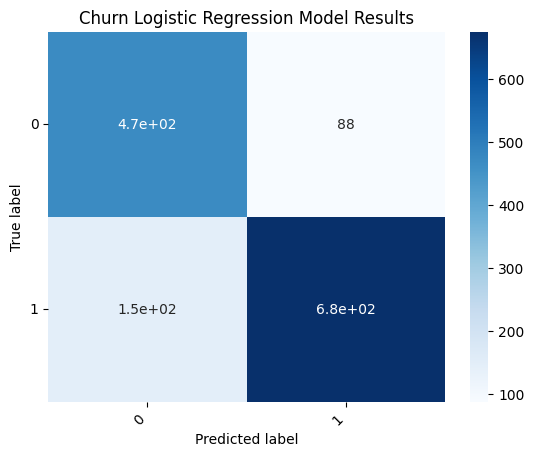

In [ ]:
import matplotlib.pyplot as plt

import seaborn as sns

plt.figure()

heatmap = sns.heatmap(df_cm, annot=True, cmap="Blues")

heatmap.yaxis.set_ticklabels(heatmap.yaxis.get_ticklabels(), rotation=0, ha='right')

heatmap.xaxis.set_ticklabels(heatmap.xaxis.get_ticklabels(), rotation=45, ha='right')

plt.ylabel('True label')

plt.xlabel('Predicted label')

plt.title('Churn Logistic Regression Model Results')

plt.show()

Finally, we can generate more useful metrics, such as: 

Precision that is the percentage of instances predicted as positive that actually were positive

Recall that is the percentage of positive instances that were predicted as positive by the model

F-measure that is a metric that combines  the precision and recall values. 

In [ ]:
from sklearn.metrics import classification_report                   #function to get the other metrixes
print('\nclassification report:\n')
print(classification_report(test_y, y_pred, target_names=['0','1']))


classification report:

              precision    recall  f1-score   support

           0       0.84      0.76      0.80       616
           1       0.82      0.88      0.85       763

    accuracy                           0.83      1379
   macro avg       0.83      0.82      0.83      1379
weighted avg       0.83      0.83      0.83      1379



In [ ]:
def check_similarity(sentence1, sentence2):
    sentence_pairs = np.array([[str(sentence1), str(sentence2)]])
    test_data = BertSemanticDataGenerator(
        sentence_pairs, labels=None, batch_size=1, shuffle=False, include_targets=False,
    )

    proba = model.predict(test_data[0])[0]
    idx = np.argmax(proba)
    proba = f"{proba[idx]: .2f}%"
    pred = labels[idx]
    return pred, proba

In [ ]:
sentence1 = "Two women are playing volleyball."
sentence2 = "Two women are playing piano."
check_similarity(sentence1, sentence2)

Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.


1/1 [==============================] - 0s 167ms/step


('0', ' 0.96%')

In [ ]:
sentence1 = "A smiling costumed woman is holding an umbrella"
sentence2 = "A happy woman in a fairy costume holds an umbrella"
check_similarity(sentence1, sentence2)

Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.


1/1 [==============================] - 0s 118ms/step


('1', ' 1.00%')

### With ktrain...

#### Import data and adjust them for classification task

**FROM LAB NOTEBOOK 7**

Pairwise classification task 

We now use the Microsoft Research Paraphrase Corpus (MRPC) to build a classifier for detecting paraphrased sentences. 
- This is an example of a paired sentence classfication task, where the prediction model takes in a **pair of texts as input** and produces a **binary label as output**.

We'll first use pandas (Python's data analysis library) to download and parse the tab-separated data.

Then, we need to format the training data in the format needed for ktrain
- so select the two columns containing strings 
- and get their values (as an 2d array) 
- then convert the array to a list of tuples (str,str) as required by ktrain (for sentence pair classification, ktrain expects a list of tuples of form (str, str)):

In [ ]:
x_train = df_train[[5, 6]].values
x_train = list(map(tuple, x_train))

y_train = df_train[4].values            # labels

In [ ]:
x_validation = df_val[[5, 6]].values
x_validation = list(map(tuple, x_validation))

y_validation = df_val[4].values

Train a model for pairwise classification: Convert the labels into binary values in order to let the output of the pairwise classification compatible with our labels. 

Arbitrary treshold >2.5 --> 1

In [ ]:
import numpy as np

treshold = 2.5

y_train_binary = np.array([1 if score>treshold else 0 for score in y_train])
y_validation_binary = np.array([1 if score>treshold else 0 for score in y_validation])

print(y_validation)
print(y_validation_binary)

[5.   4.75 5.   ... 2.   0.   0.  ]
[1 1 1 ... 0 0 0]


#### Build and train the model

Import a pretrained version of BERT for two classes classification

In [ ]:
import ktrain
from ktrain import text

1.   Load the model (e.g. 'distilbert-base-uncased', 'bert-base-uncased')

In [ ]:
MODEL_NAME = 'bert-base-uncased'
transformer = text.Transformer(MODEL_NAME, maxlen=128, class_names=['not paraphrase', 'paraphrase'])

2. Process the training/test data

In [ ]:
processed_train = transformer.preprocess_train(x_train, y_train_binary)
processed_validation = transformer.preprocess_test(x_validation, y_validation_binary)

preprocessing train...
language: en
sentence pairs detected


Is Multi-Label? False
preprocessing test...
language: en
sentence pairs detected


3. Create a model and learner

In [ ]:
model = transformer.get_classifier()
learner = ktrain.get_learner(model, train_data=processed_train, val_data=processed_validation, batch_size=32)

4.   Train the model 

In [ ]:
learner.fit_onecycle(5e-5, 4)



begin training using onecycle policy with max lr of 5e-05...
Epoch 1/4
180/180 [==============================] - 187s 899ms/step - loss: 0.4949 - accuracy: 0.7474 - val_loss: 0.3767 - val_accuracy: 0.8273
Epoch 2/4
180/180 [==============================] - 155s 862ms/step - loss: 0.3033 - accuracy: 0.8742 - val_loss: 0.3695 - val_accuracy: 0.8407
Epoch 3/4
180/180 [==============================] - 152s 847ms/step - loss: 0.1542 - accuracy: 0.9428 - val_loss: 0.4041 - val_accuracy: 0.8347
Epoch 4/4
180/180 [==============================] - 151s 841ms/step - loss: 0.0488 - accuracy: 0.9833 - val_loss: 0.5782 - val_accuracy: 0.8387


5.   Evaluate the model

In [ ]:
learner.validate(class_names=transformer.get_classes())

47/47 [==============================] - 12s 198ms/step
                precision    recall  f1-score   support

not paraphrase       0.83      0.85      0.84       750
    paraphrase       0.85      0.82      0.84       750

      accuracy                           0.84      1500
     macro avg       0.84      0.84      0.84      1500
  weighted avg       0.84      0.84      0.84      1500



array([[641, 109],
       [133, 617]])

Have a look to the model

In [ ]:
print(model.summary())

Model: "tf_bert_for_sequence_classification_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bert (TFBertMainLayer)      multiple                  109482240 
                                                                 
 dropout_151 (Dropout)       multiple                  0         
                                                                 
 classifier (Dense)          multiple                  1538      
                                                                 
Total params: 109,483,778
Trainable params: 109,483,778
Non-trainable params: 0
_________________________________________________________________
None


#### Test the model

6.   Make some predictions with it

In [ ]:
x_test = df_test[[5, 6]].values
x_test = list(map(tuple, x_test))

y_test = df_test[4].values

y_test_binary = np.array([1 if score>treshold else 0 for score in y_test])

See how the prediction works in practice (example: here "paraphrase" stays for "similar")

In [ ]:
import random
i = random.randint(0, len(x_test)-1)

In [ ]:
print("Sentence 1:     "+x_test[i][0])
print("Sentence 2:     "+x_test[i][1])
print("Label:          "+str(y_test[i]))
print("Label (binary): "+str(y_test_binary[i]))

predictor = ktrain.get_predictor(learner.model, preproc=transformer)
pred = predictor.predict((x_test[i][0], x_test[i][1]))

print("Preditiction:   "+str(pred))

Sentence 1:     A woman is cracking eggs.
Sentence 2:     A man is talking to a woman.
Label:          0.0
Label (binary): 0
Preditiction:   not paraphrase


Compute pearson correlation coefficient

In [ ]:
scores = []
predictor = ktrain.get_predictor(learner.model, preproc=transformer)

for i in range(len(x_test)):
  pred = predictor.predict((x_test[i][0], x_test[i][1]))
  scores.append(pred)

In [ ]:
scores_binary = np.array([1 if pred=='paraphrase' else 0 for pred in scores])

In [ ]:
pearson_correlation = scipy.stats.pearsonr(scores_binary, y_test_binary)
print('Pearson correlation coefficient = {0}\np-value = {1}'.format(
    pearson_correlation[0], pearson_correlation[1]))

Pearson correlation coefficient = 0.6622139278303361
p-value = 8.390211563061497e-175


In [ ]:
df_test['classification_ktrain']=scores_binary
df_test

,0,1,2,3,4,5,6,regression_ktrain,regression_chatGPT,classification_ktrain
0,main-captions,MSRvid,2012test,24,2.5,A girl is styling her hair.,A girl is brushing her hair.,4.019412,2.154089,1
1,main-captions,MSRvid,2012test,33,3.6,A group of men play soccer on the beach.,A group of boys are playing soccer on the beach.,4.212562,4.204353,1
2,main-captions,MSRvid,2012test,45,5.0,One woman is measuring another woman's ankle.,A woman measures another woman's ankle.,4.785541,4.983991,1
3,main-captions,MSRvid,2012test,63,4.2,A man is cutting up a cucumber.,A man is slicing a cucumber.,4.833124,4.811834,1
4,main-captions,MSRvid,2012test,66,1.5,A man is playing a harp.,A man is playing a keyboard.,2.131255,2.092705,0
...,...,...,...,...,...,...,...,...,...,...
1374,main-news,headlines,2016,1354,0.0,"Philippines, Canada pledge to further boost re...",Philippines saves 100 after ferry sinks,1.086582,1.114442,0
1375,main-news,headlines,2016,1360,1.0,Israel bars Palestinians from Jerusalem's Old ...,"Two-state solution between Palestinians, Israe...",1.489657,1.216195,0
1376,main-news,headlines,2016,1368,1.0,How much do you know about Secret Service?,Lawmakers from both sides express outrage at S...,1.432360,1.194979,0
1377,main-news,headlines,2016,1420,0.0,Obama Struggles to Soothe Saudi Fears As Iran ...,Myanmar Struggles to Finalize Voter Lists for ...,0.445774,0.283832,0


Print the classification report

In [ ]:
from sklearn.metrics import classification_report                   #function to get the other metrixes
print('\nclassification report:\n')
print(classification_report(y_test_binary, scores_binary, target_names=['0','1']))


classification report:

              precision    recall  f1-score   support

           0       0.82      0.81      0.81       616
           1       0.85      0.85      0.85       763

    accuracy                           0.83      1379
   macro avg       0.83      0.83      0.83      1379
weighted avg       0.83      0.83      0.83      1379



Plot the confusion matrix

In [ ]:
import matplotlib.pyplot as plt  
from sklearn.metrics import confusion_matrix

In [ ]:
conmat = confusion_matrix(scores_binary, y_test_binary)  
#create a dataframe from the confusion matrix array, called df_cm:

val = np.mat(conmat) 

classnames = list(set(y_test_binary))

df_cm = pd.DataFrame( val, index=classnames, columns=classnames )

print(df_cm)

     0    1
0  497  111
1  119  652


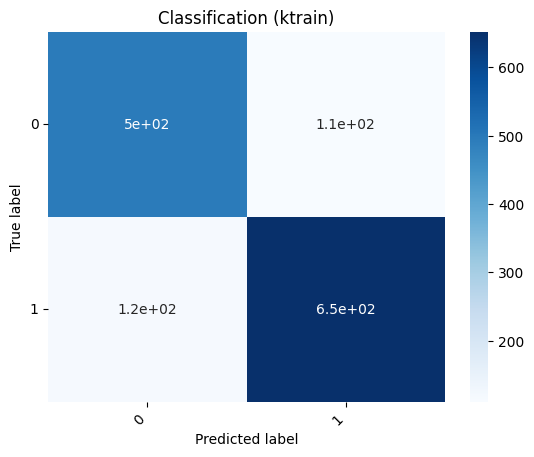

In [ ]:
import matplotlib.pyplot as plt

import seaborn as sns

plt.figure()
heatmap = sns.heatmap(df_cm, annot=True, cmap="Blues")
heatmap.yaxis.set_ticklabels(heatmap.yaxis.get_ticklabels(), rotation=0, ha='right')
heatmap.xaxis.set_ticklabels(heatmap.xaxis.get_ticklabels(), rotation=45, ha='right')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.title('Classification (ktrain)')

plt.show()

#### Save

In [ ]:
df_test.to_csv("TEMP_final_models.csv")

# Summary

In the notebook we proposed many techniques for STS task. The best results are obtained by far by Transformers. We report a table with a comparison between the Pearson correlation coefficients/accuracy computed for the different models. These results were displayed before along the notebook and now are collected here:

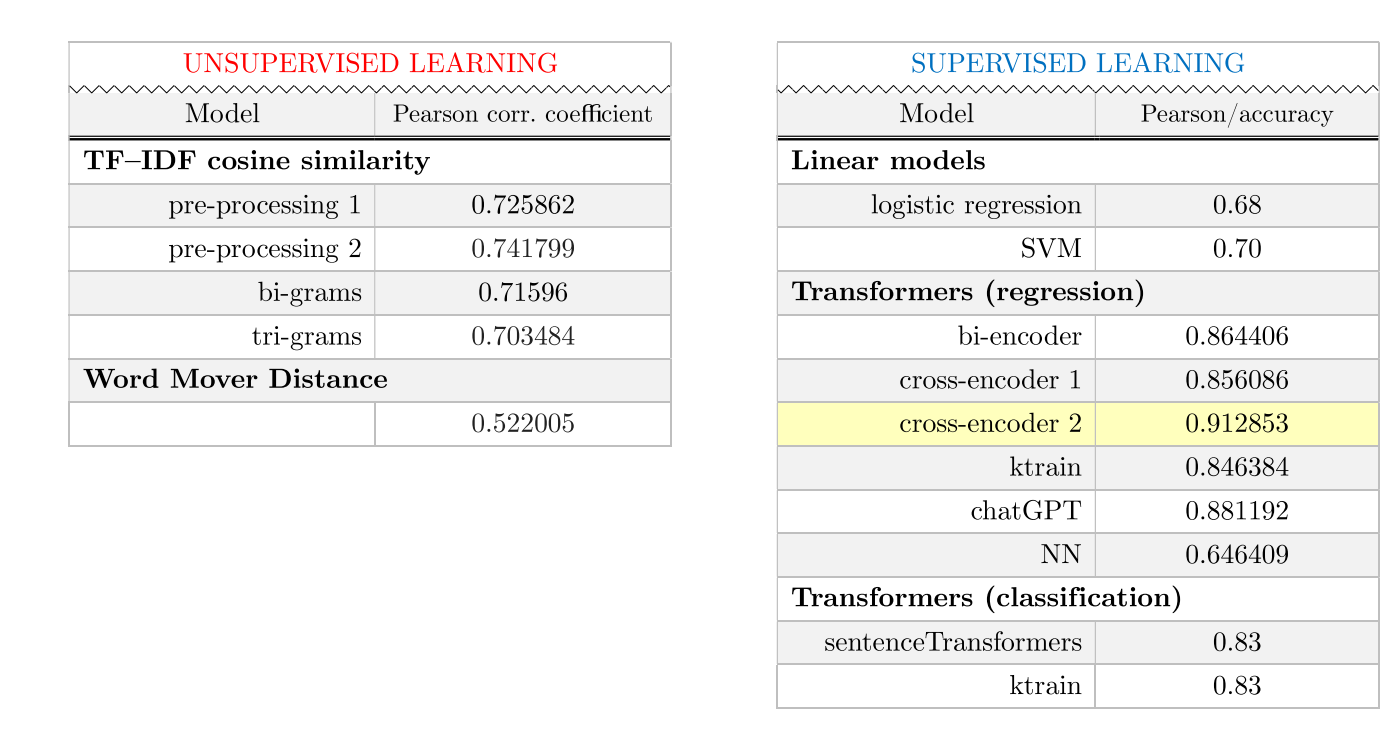

Cross-Encoder is the model that returns the best predictions!

# Developements

Since the time available for finishing the project was not much, we couldn't complete all the analysis we had in mind. However, we leave here some ideas about the next possible developements.

## Improve the pre-processing

We noticed that some sentences don't contain any informative word, thus when we pre-process them (e.g. in the first section on the notebook, dedicated to TF-IDF) they become empty string. In these cases the prediction is certainly uninformative about the similarity. However, removing pre-processing didn't affect much the predictions.

## Split the dataset

Since the dataset is composed of sentences coming from three different sources, another idea could be to split it and to perform the STS task separately. Maybe the predictions are different for each class or each of them performs better with a different model with respect to the other. All these aspects could be investigated. 

In [ ]:
def drop_dataset(df, name):
  return df.drop( df[ df[0] != name ].index )

In [ ]:
df_cut1 = drop_dataset(df_train, 'main-captions') 
df_cut2 = drop_dataset(df_train, 'main-forum') 
df_cut3 = drop_dataset(df_train, 'main-news') 

Create the different datasets

In [ ]:
x_train = df_train[[5, 6]].values
x_train = list(map(tuple, x_train))

x_train1 = df_cut1[[5, 6]].values
x_train1 = list(map(tuple, x_train1))

x_train2 = df_cut2[[5, 6]].values
x_train2 = list(map(tuple, x_train2))

x_train3 = df_cut3[[5, 6]].values
x_train3 = list(map(tuple, x_train3))

y_train = df_train[4].values/5.0
y_train1 = df_cut1[4].values/5.0
y_train2 = df_cut2[4].values/5.0
y_train3 = df_cut3[4].values/5.0

Do the same also for validation

In [ ]:
df_cut1 = drop_dataset(df_val, 'main-captions') 
df_cut2 = drop_dataset(df_val, 'main-forum') 
df_cut3 = drop_dataset(df_val, 'main-news') 

In [ ]:
x_val = df_val[[5, 6]].values
x_val = list(map(tuple, x_val))

x_val1 = df_cut1[[5, 6]].values
x_val1 = list(map(tuple, x_val1))

x_val2 = df_cut2[[5, 6]].values
x_val2 = list(map(tuple, x_val2))

x_val3 = df_cut3[[5, 6]].values
x_val3 = list(map(tuple, x_val3))

y_val = df_val[4].values/5.0
y_val1 = df_cut1[4].values/5.0
y_val2 = df_cut2[4].values/5.0
y_val3 = df_cut3[4].values/5.0

Models and training...plus comparative analysis

## Clustering

Another task we wanted to address was Clustering. This study goes beyond the purposes of the STS task, but could be interesting. In fact, since the sentences come from three different sources, we could try to understand whether there's some pattern for each of the three classes and we can recognise it or not.

# Thanks for the attention :)